# Proyek Data Mining: Analisis Kampanye Pemasaran Bank

## 1. Business Understanding

**Latar Belakang:**
Bank memiliki data hasil kampanye pemasaran telepon langsung. Masalah utama dalam bisnis perbankan adalah efisiensi pemasaran; menghubungi semua nasabah memakan biaya dan waktu tinggi, sementara tingkat konversi (nasabah yang akhirnya deposito) biasanya rendah.

**Tujuan Proyek:**
1.  Clustering: Mengelompokkan nasabah berdasarkan karakteristik profil dan perilaku ekonomi untuk segmentasi pasar.
2.  Classification: Membangun model prediksi untuk menentukan apakah seorang nasabah akan berlangganan deposito (yes) atau tidak (no).

**Metodologi:** CRISP-DM (Cross-Industry Standard Process for Data Mining).

## 2. Data Understanding
Tahap
 mengeksplorasi data untuk memahami kualitas, distribusi, dan hubungan antar fitur sebelum melakukan manipulasi data.

### 2.1 Install & Import Library

In [1]:
# Install library
!pip install -q missingno

# Import semua library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


### 2.2 Load Dataset

In [2]:
# Load dataset (separator pakai titik koma ';')
df = pd.read_csv('bank-additional-full.csv', sep=';')

print(f' Dataset sudah terbaca')
print(f'   Jumlah baris  : {df.shape[0]:,}')
print(f'   Jumlah kolom  : {df.shape[1]}')
print(f'   Ukuran dataset: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

 Dataset sudah terbaca
   Jumlah baris  : 41,188
   Jumlah kolom  : 21
   Ukuran dataset: 26.80 MB


### 2.3 Preview dan Info Dataset

In [3]:
# Lihat 5 baris pertama
print(' 5 Baris Pertama ')
display(df.head())

print('\n Info Tipe Data ')
df.info()

print('\n Statistik Deskriptif (Numerik)')
display(df.describe())

print('\n Statistik Deskriptif (Kategorikal)')
display(df.describe(include='object'))

 5 Baris Pertama 


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no



 Info Tipe Data 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10



 Statistik Deskriptif (Kategorikal)


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


### 2.4 Cek Miss Value dan Duplikat

= Missing Value per Kolom =


,Jumlah Missing,Persentase (%)


 Tidak ada missing value (NaN)!

 Nilai "unknown" per Kolom Kategorikal 


,Jumlah,Persen (%)
job,330.00,0.80
marital,80.00,0.19
education,1731.00,4.20
default,8597.00,20.87
housing,990.00,2.40
loan,990.00,2.40



= Duplikat =
Jumlah baris duplikat: 12


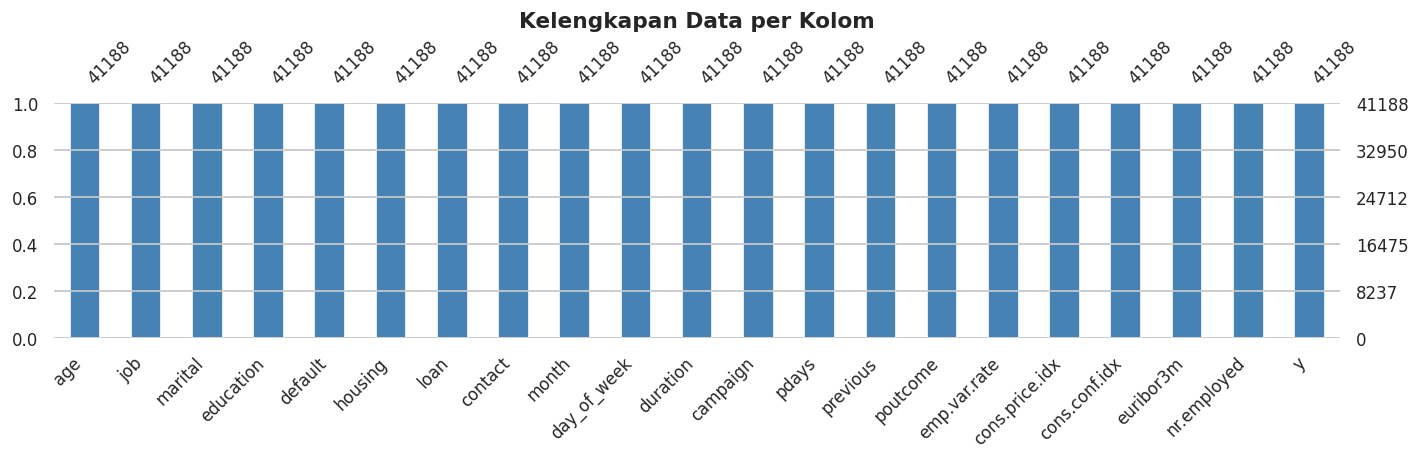

In [4]:
# Cek missing value
print('= Missing Value per Kolom =')
missing = pd.DataFrame({
    'Jumlah Missing'  : df.isnull().sum(),
    'Persentase (%)'  : (df.isnull().sum() / len(df) * 100).round(2)
})
display(missing[missing['Jumlah Missing'] > 0])

if df.isnull().sum().sum() == 0:
    print(' Tidak ada missing value (NaN)!')

# Cek nilai 'unknown' (missing terselubung di dataset ini)
print('\n Nilai "unknown" per Kolom Kategorikal ')
cat_cols = df.select_dtypes(include='object').columns
unknown_counts = {}
for col in cat_cols:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        unknown_counts[col] = {'Jumlah': count, 'Persen (%)': round(count/len(df)*100, 2)}

if unknown_counts:
    display(pd.DataFrame(unknown_counts).T)
else:
    print('Tidak ada nilai unknown.')

#  Cek duplikat
dup = df.duplicated().sum()
print(f'\n= Duplikat =' )
print(f'Jumlah baris duplikat: {dup}')

#  Visualisasi missing value
fig, ax = plt.subplots(figsize=(12, 4))
msno.bar(df, ax=ax, color='steelblue', fontsize=10)
ax.set_title('Kelengkapan Data per Kolom', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.5 Distribusi Target Variable (y)

=== Distribusi Target Variable (y) ===


,Jumlah,Persentase (%)
y,,
no,36548,88.73
yes,4640,11.27


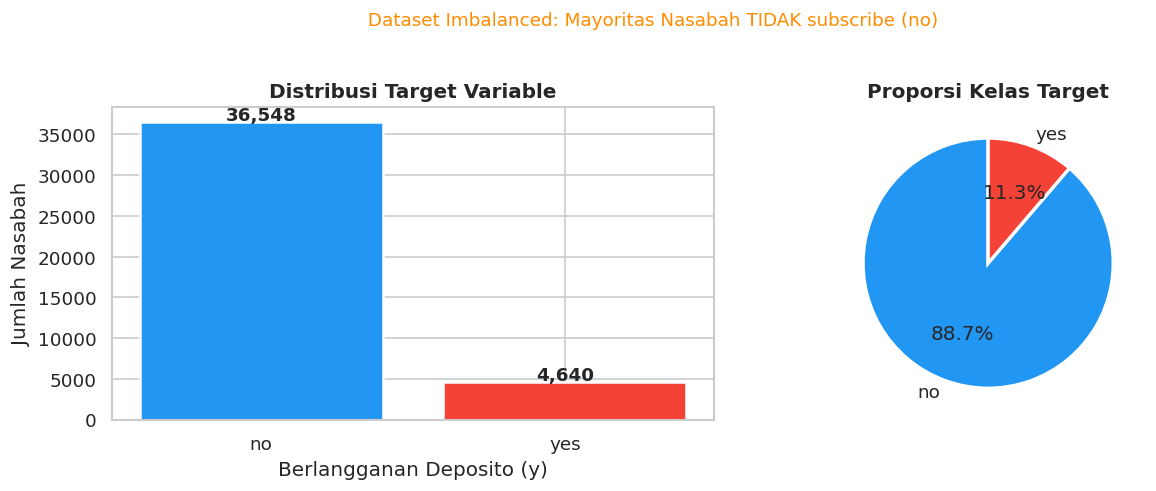


 Rasio imbalance: 1 : 7.9


In [5]:
# Hitung distribusi target
target_counts = df['y'].value_counts()
target_pct    = df['y'].value_counts(normalize=True) * 100

print('=== Distribusi Target Variable (y) ===')
summary = pd.DataFrame({'Jumlah': target_counts, 'Persentase (%)': target_pct.round(2)})
display(summary)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
colors = ['#2196F3', '#F44336']
bars = axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Target Variable', fontweight='bold')
axes[0].set_xlabel('Berlangganan Deposito (y)')
axes[0].set_ylabel('Jumlah Nasabah')
for bar, val in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas Target', fontweight='bold')

plt.suptitle(' Dataset Imbalanced: Mayoritas Nasabah TIDAK subscribe (no)',
             fontsize=11, color='darkorange', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n Rasio imbalance: 1 : {round(target_counts["no"]/target_counts["yes"], 1)}')

### 2.6  Distribusi Fitur Numerik

Kolom numerik (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


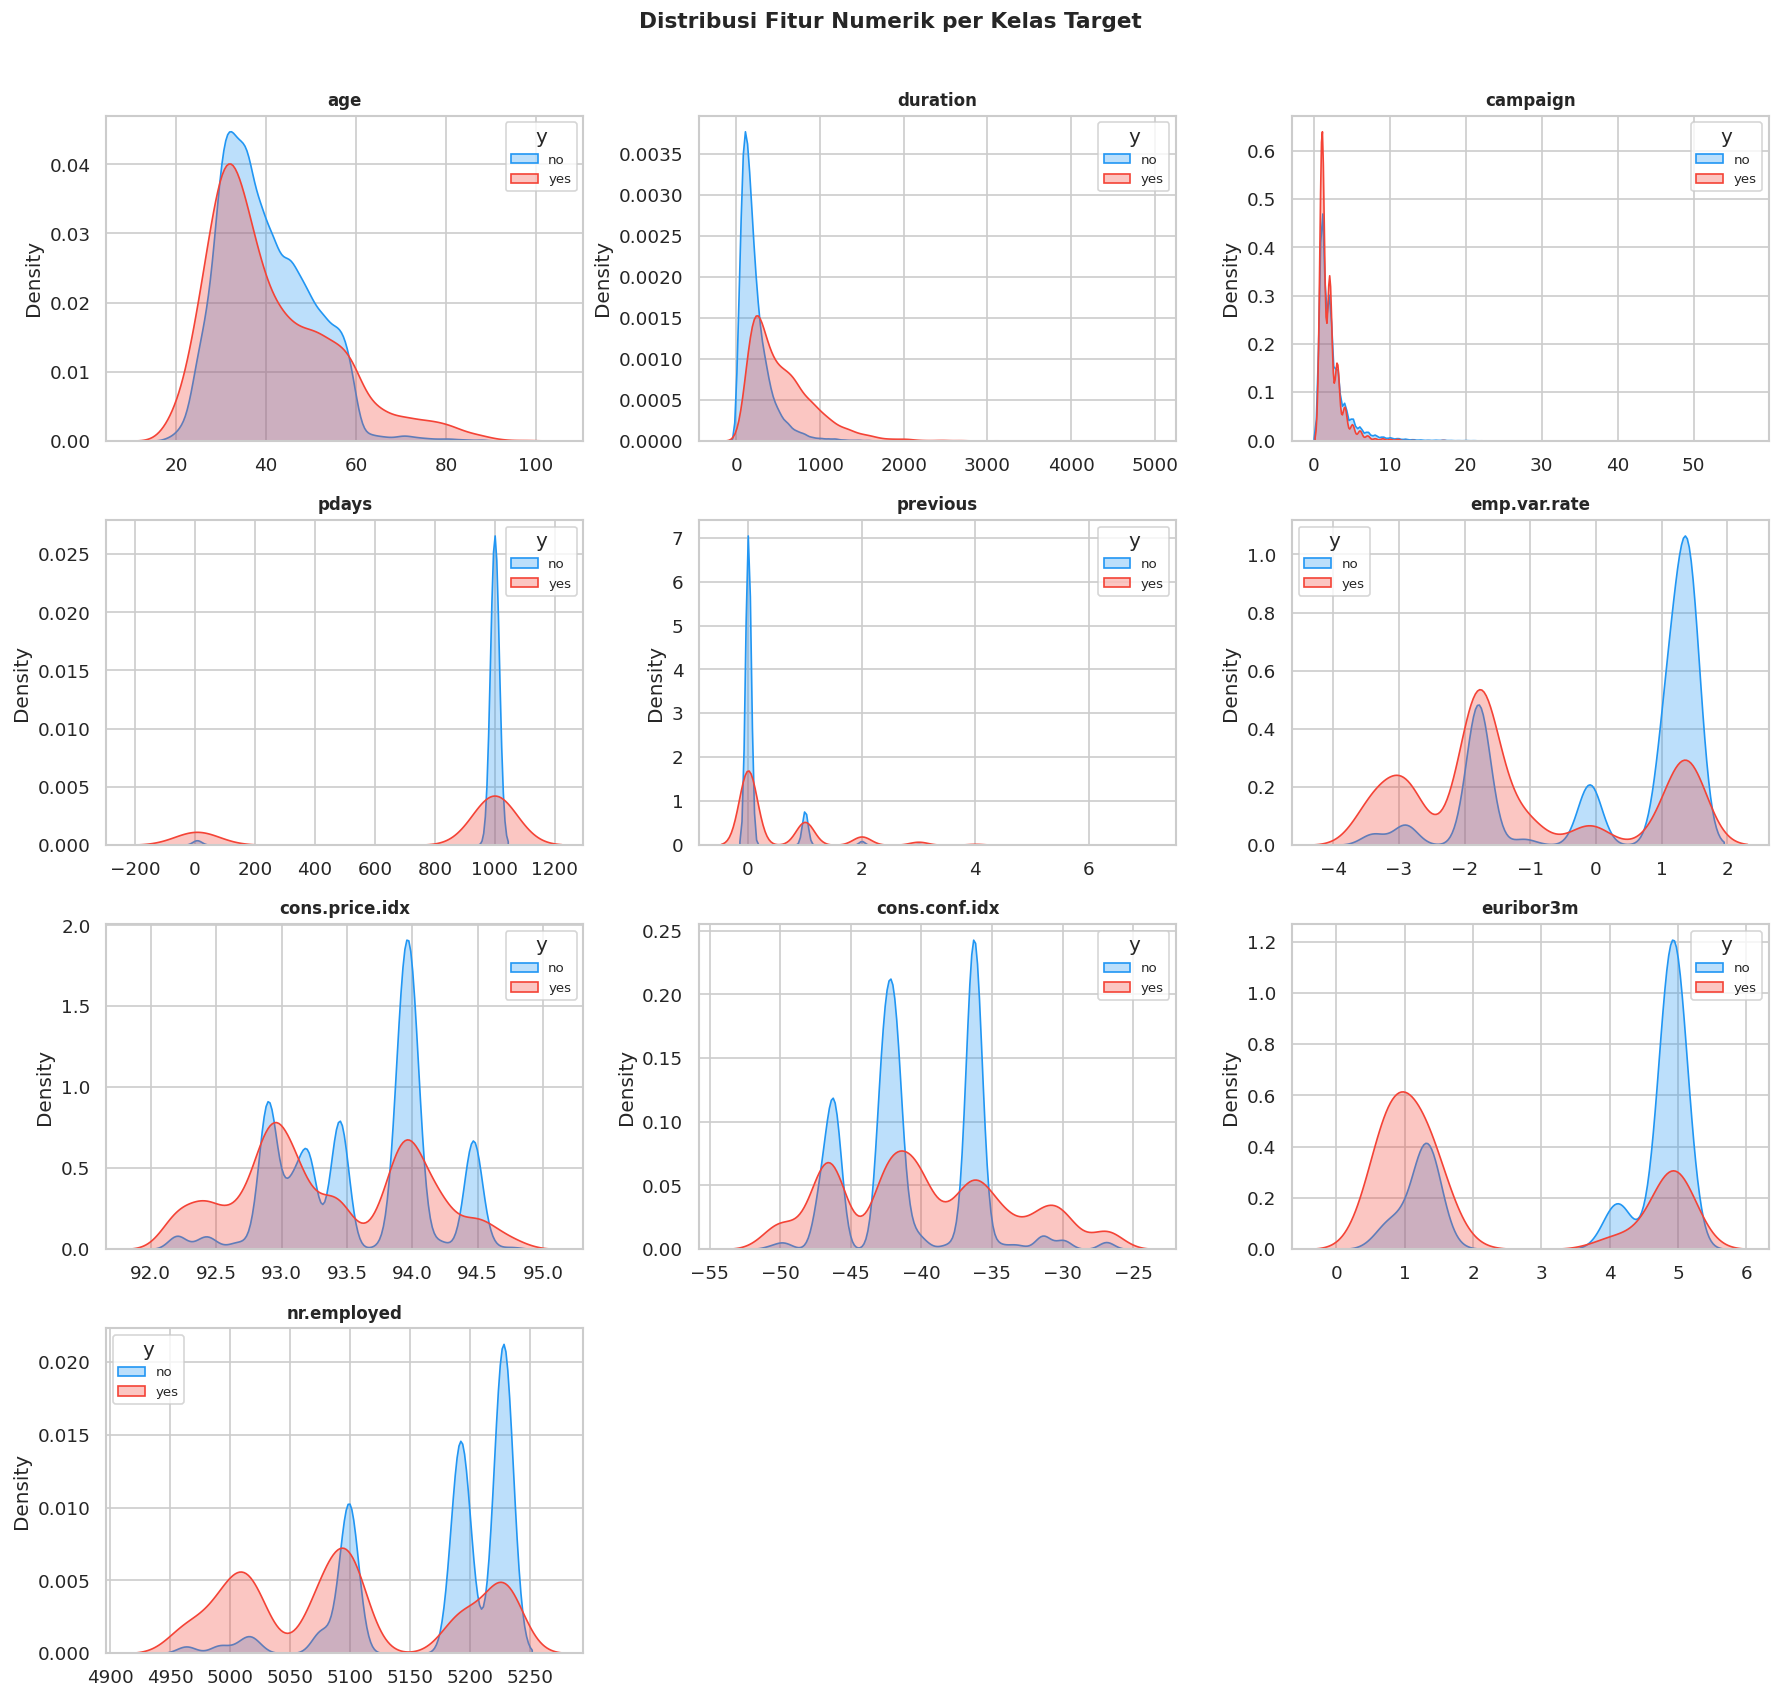

In [6]:
# Daftar kolom numerik
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'Kolom numerik ({len(num_cols)}): {num_cols}')

# Plot histogram + KDE untuk setiap fitur numerik
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    # Plot terpisah per kelas target
    for label, color in zip(['no', 'yes'], ['#2196F3', '#F44336']):
        sns.kdeplot(df[df['y'] == label][col], ax=ax, label=label,
                    color=color, fill=True, alpha=0.3)
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.legend(title='y', fontsize=8)

# Sembunyikan axes kosong
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik per Kelas Target', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.7 Boxplot & Deteksi Outlier

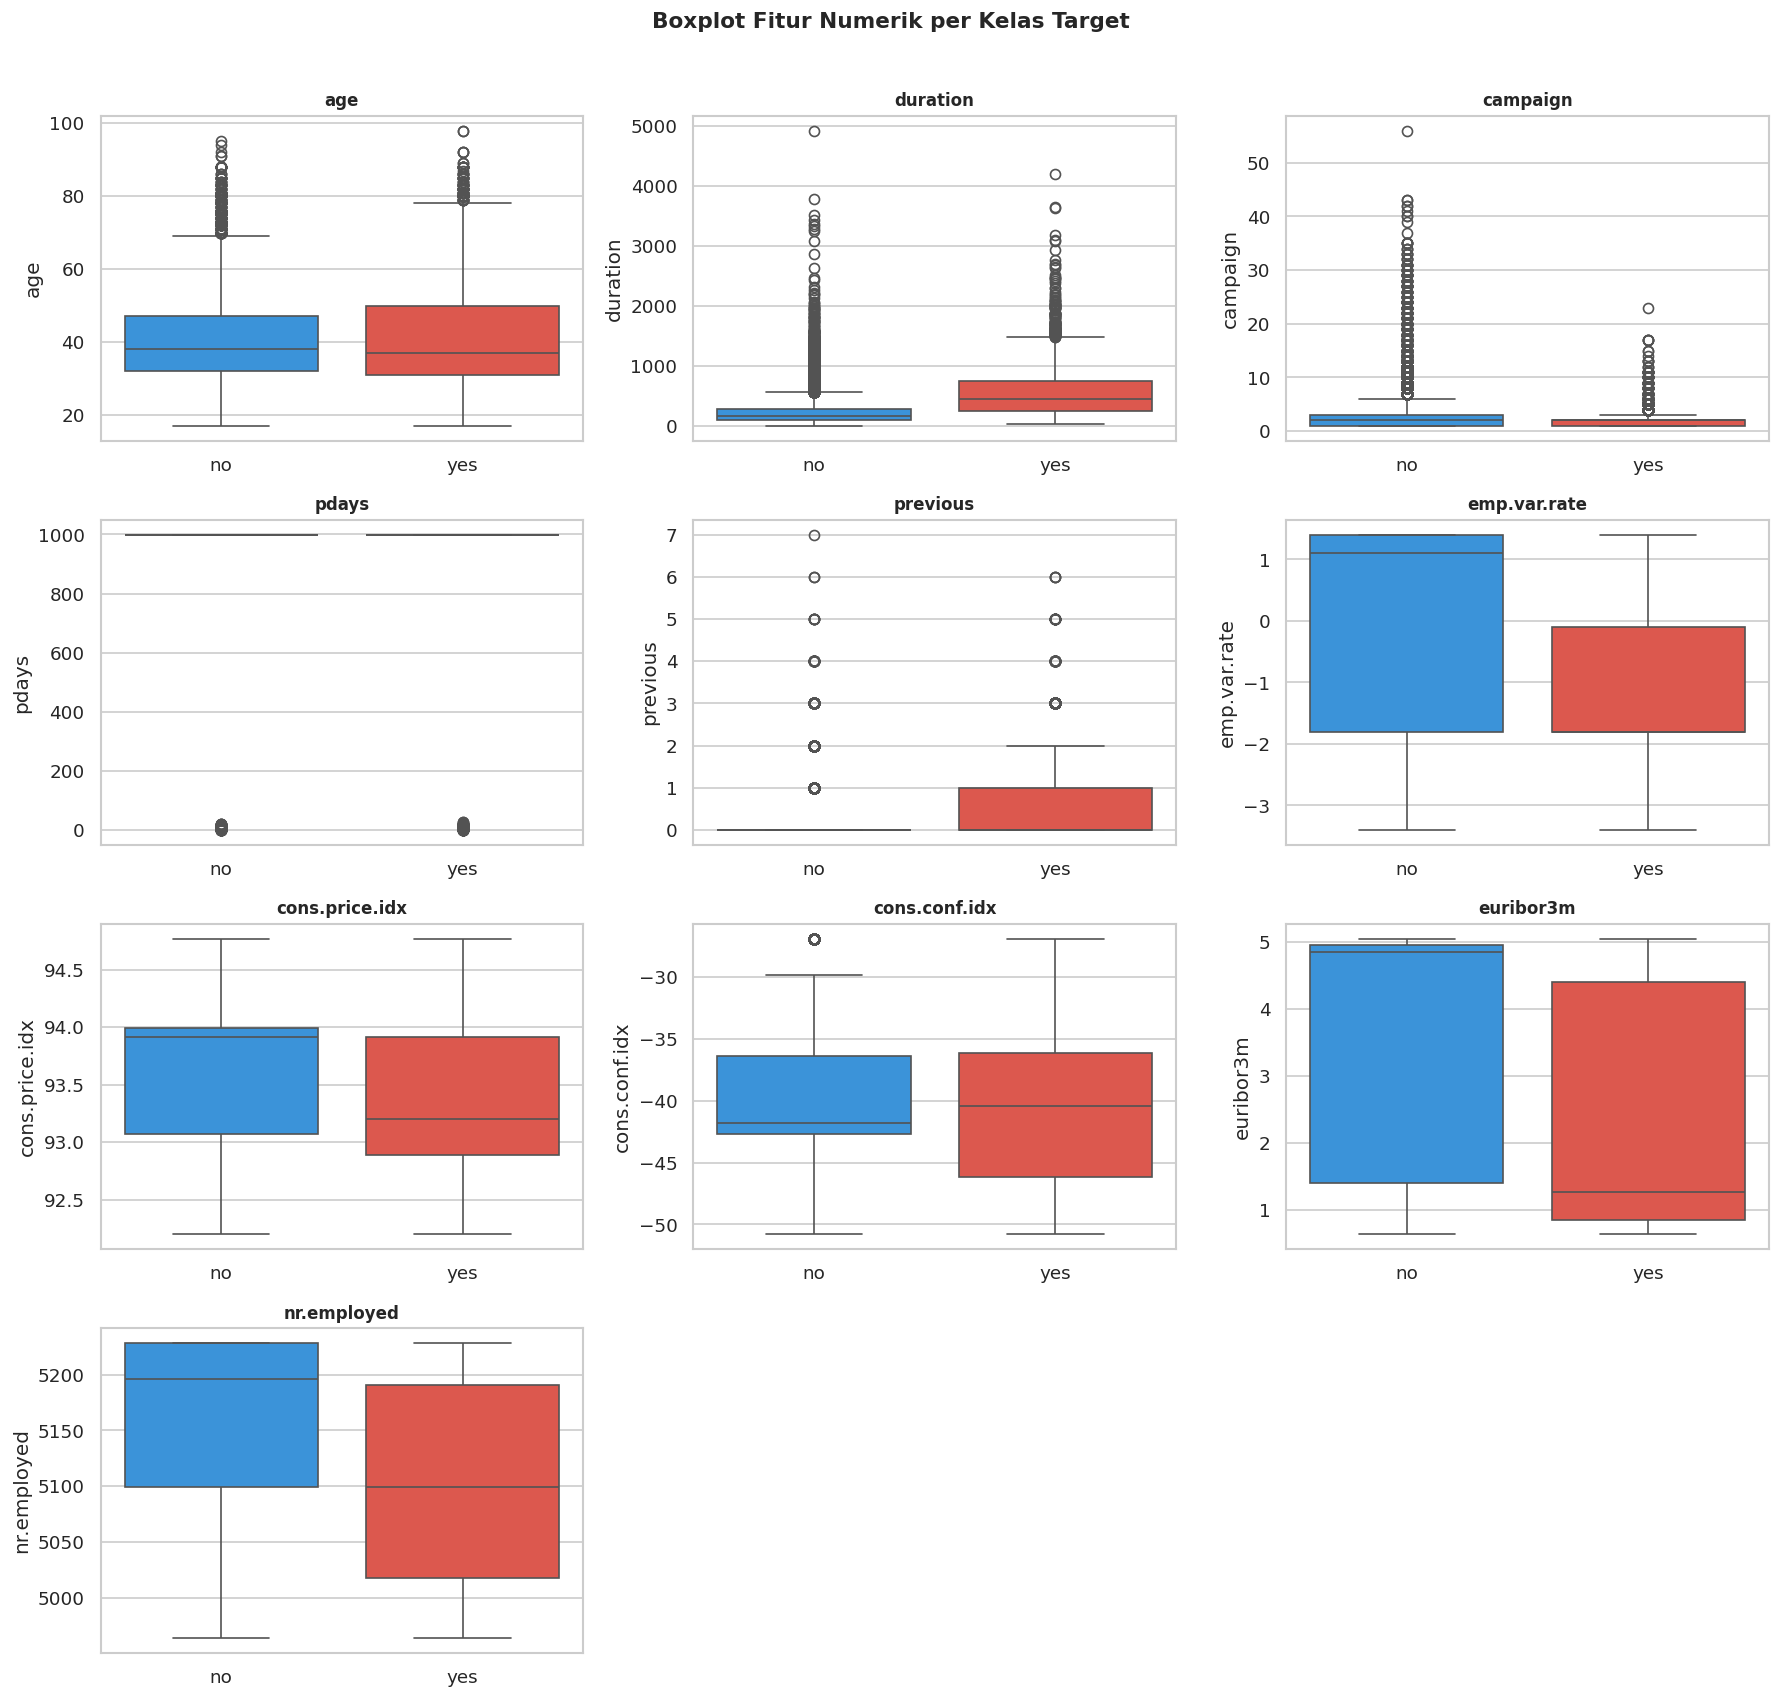


=== Ringkasan Outlier (Metode IQR) ===


,Jumlah Outlier,Persen (%)
previous,5625.00,13.66
duration,2963.00,7.19
campaign,2406.00,5.84
pdays,1515.00,3.68
age,469.00,1.14
cons.conf.idx,447.00,1.09
emp.var.rate,0.00,0.00
cons.price.idx,0.00,0.00
euribor3m,0.00,0.00
nr.employed,0.00,0.00


In [7]:
# Boxplot untuk deteksi outlier
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

outlier_summary = {}
for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.boxplot(data=df, x='y', y=col, ax=ax,
                palette={'no': '#2196F3', 'yes': '#F44336'})
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xlabel('')

    # Hitung outlier dengan metode IQR
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary[col] = {'Jumlah Outlier': n_out, 'Persen (%)': round(n_out/len(df)*100, 2)}

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot Fitur Numerik per Kelas Target', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\n=== Ringkasan Outlier (Metode IQR) ===')
display(pd.DataFrame(outlier_summary).T.sort_values('Jumlah Outlier', ascending=False))

### 2.8 Distribusi Fitur Kategorikal

Kolom kategorikal (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


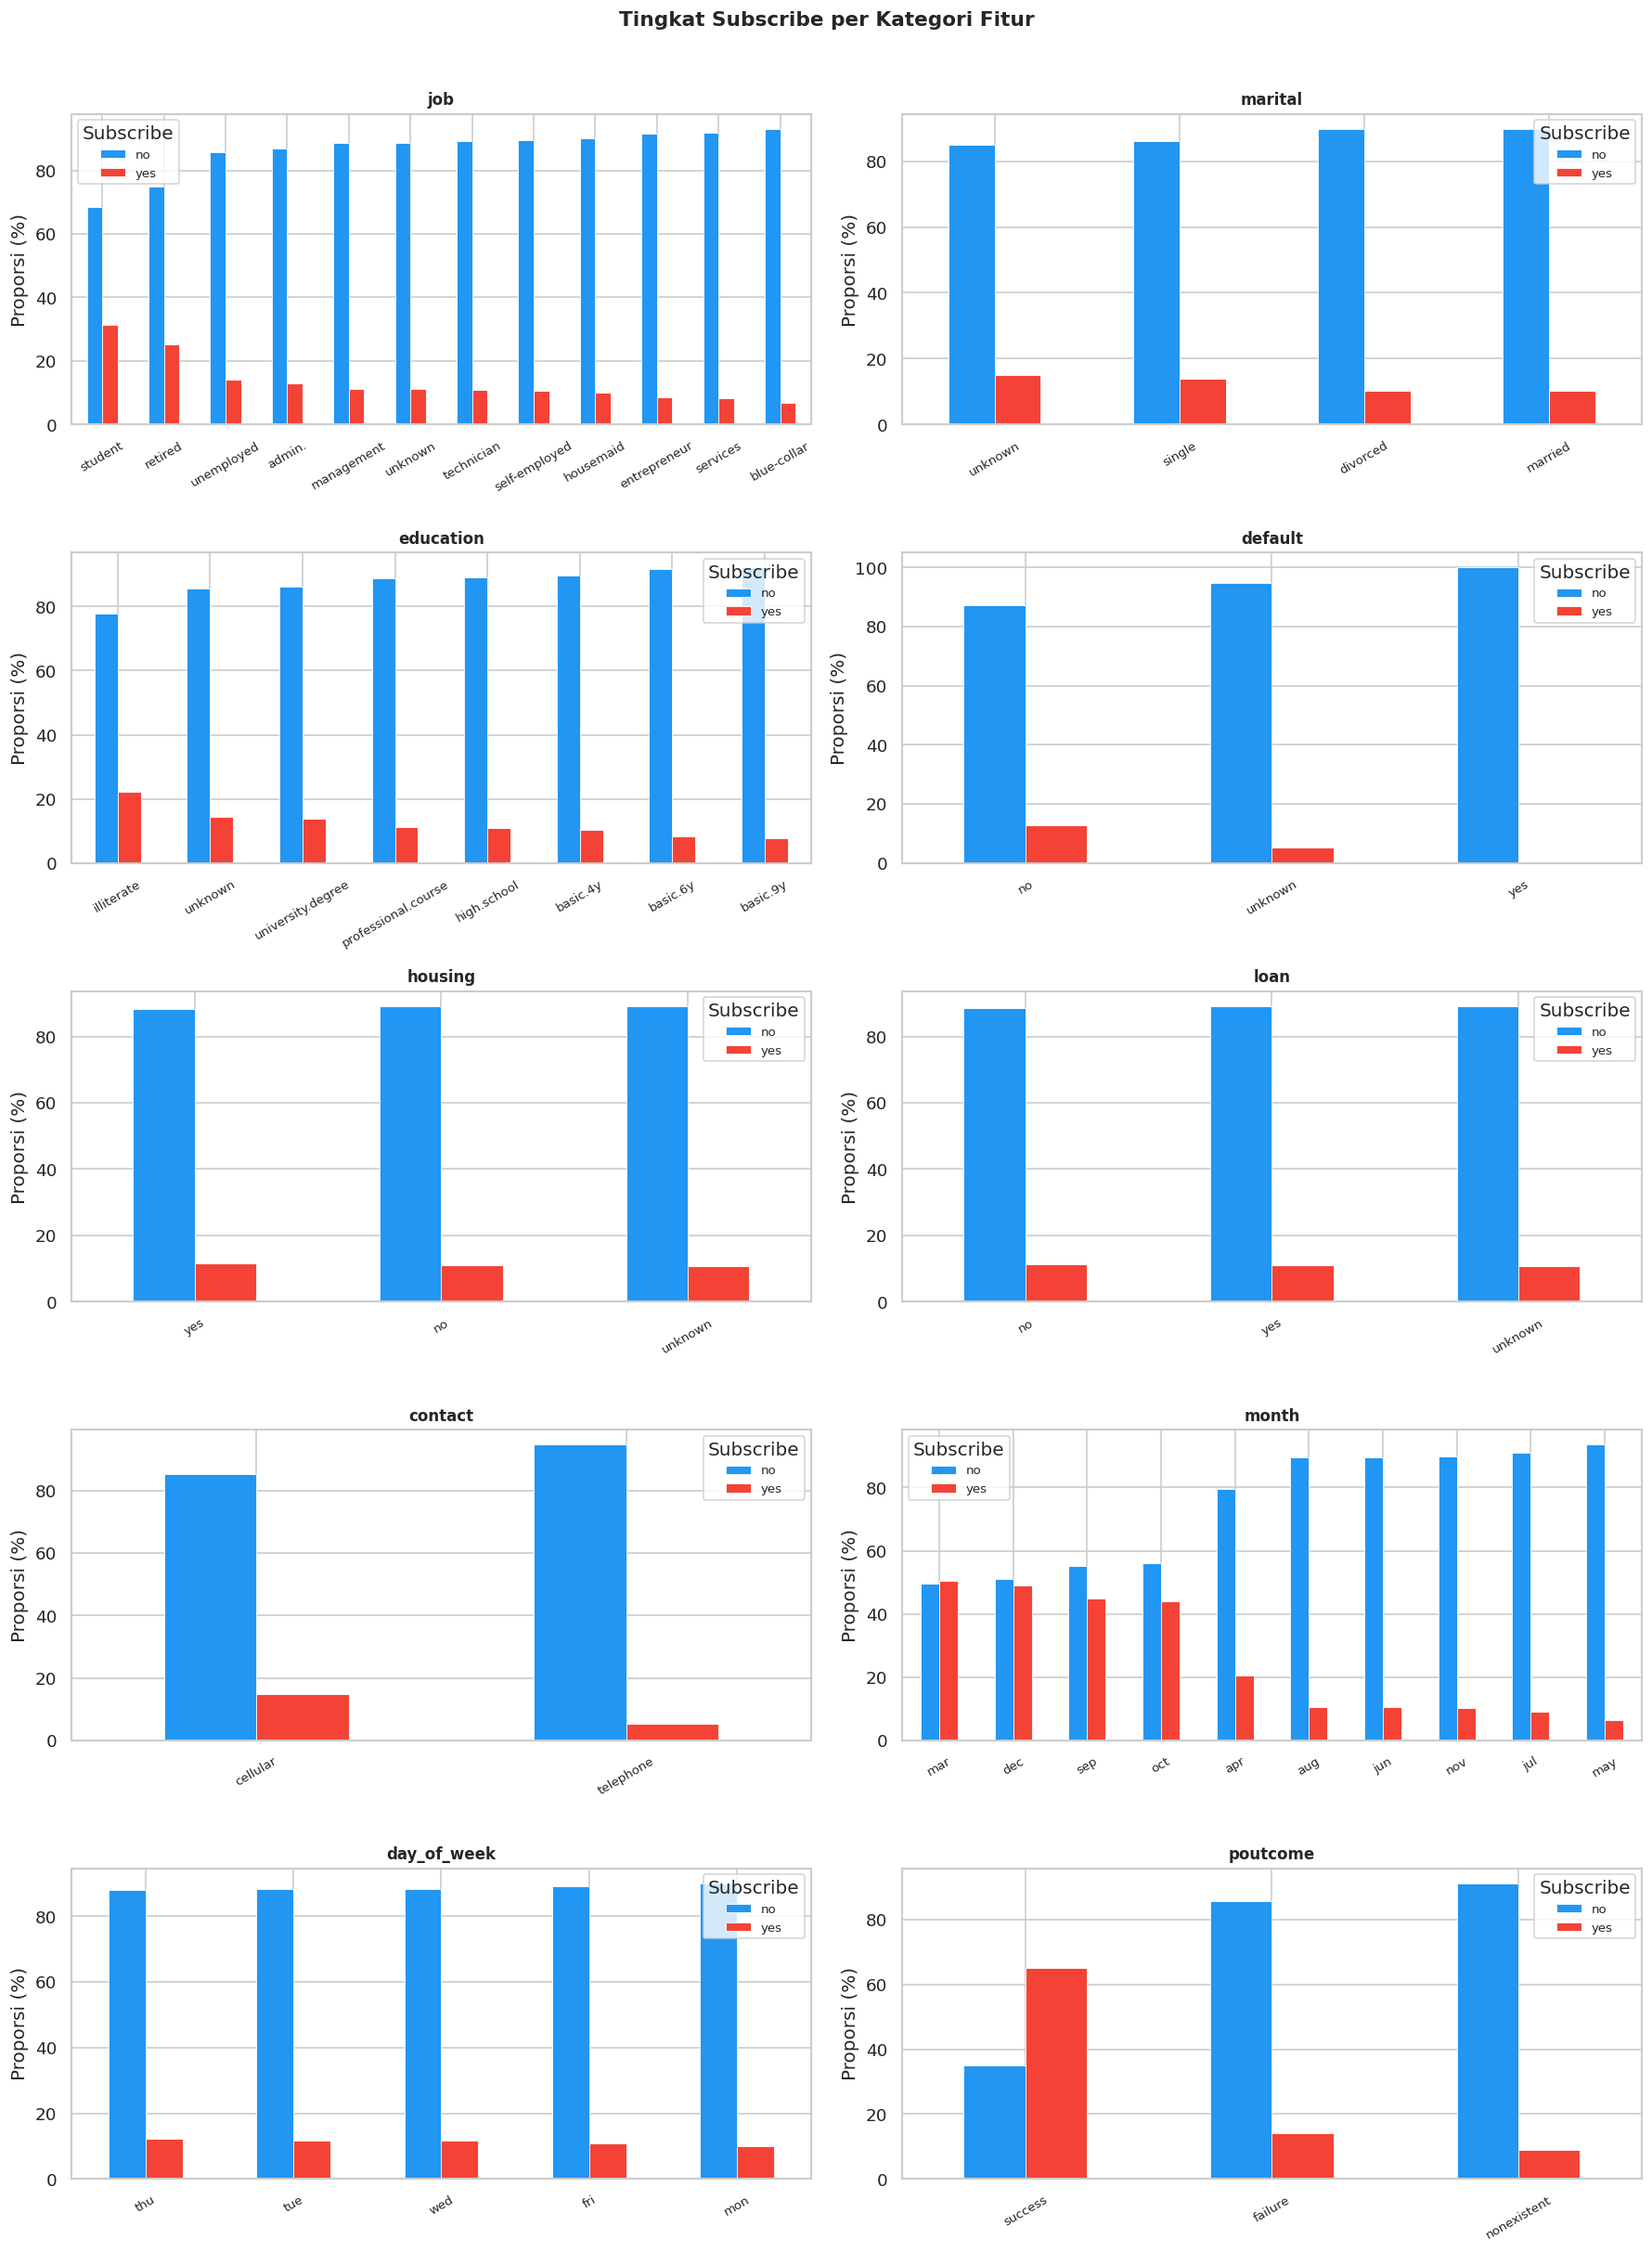

In [8]:
# Kolom kategorikal (kecuali target)
cat_cols_plot = [c for c in df.select_dtypes(include='object').columns if c != 'y']
print(f'Kolom kategorikal ({len(cat_cols_plot)}): {cat_cols_plot}')

n_cols_c = 2
n_rows_c = (len(cat_cols_plot) + n_cols_c - 1) // n_cols_c
fig, axes = plt.subplots(n_rows_c, n_cols_c, figsize=(15, n_rows_c * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols_plot):
    ax = axes[i]
    # Menghitung subscription rate per kategori
    grouped = df.groupby(col)['y'].value_counts(normalize=True).unstack().fillna(0) * 100
    grouped.sort_values('yes', ascending=False).plot(
        kind='bar', ax=ax,
        color=['#2196F3', '#F44336'],
        edgecolor='white', linewidth=0.5
    )
    ax.set_title(f'{col}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Proporsi (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.legend(title='Subscribe', fontsize=8)

for j in range(len(cat_cols_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Tingkat Subscribe per Kategori Fitur', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.9 Heatmap Korelasi Fitur Numerik

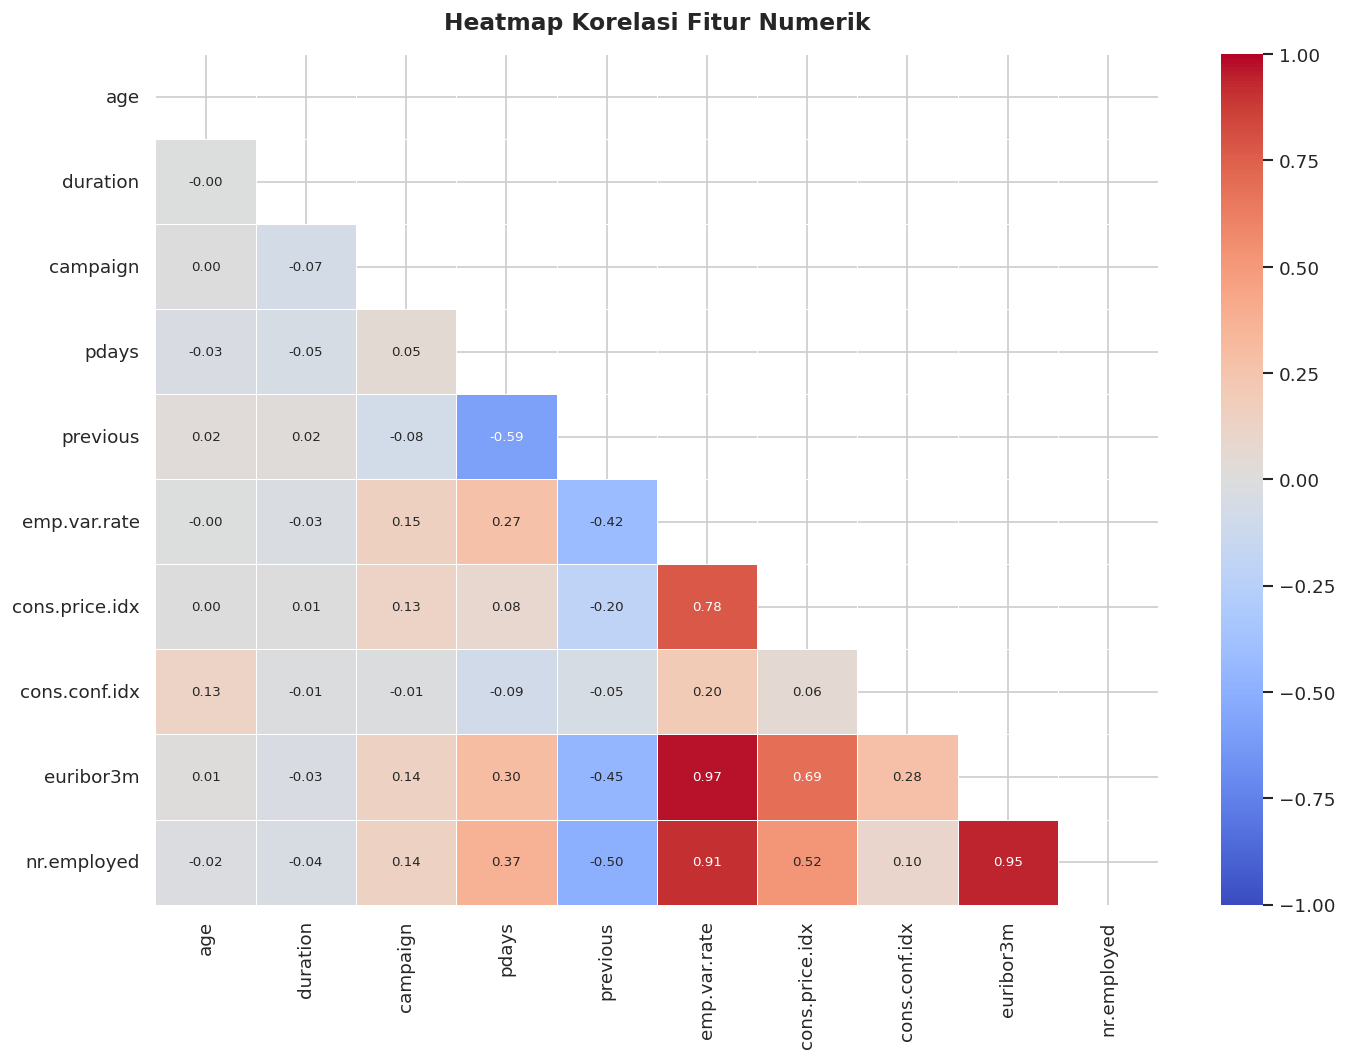

=== Pasangan Fitur dengan Korelasi Tinggi (|r| > 0.5) ===


,Fitur 1,Fitur 2,Korelasi
2,euribor3m,emp.var.rate,0.97
7,nr.employed,euribor3m,0.94
5,nr.employed,emp.var.rate,0.91
1,cons.price.idx,emp.var.rate,0.78
3,euribor3m,cons.price.idx,0.69
0,previous,pdays,-0.59
6,nr.employed,cons.price.idx,0.52
4,nr.employed,previous,-0.50


In [9]:
# Hitung korelasi Pearson
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Sembunyikan segitiga atas

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 8},
    ax=ax
)
ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Tampilkan pasangan dengan korelasi tinggi (> 0.5)
print('=== Pasangan Fitur dengan Korelasi Tinggi (|r| > 0.5) ===')
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.5:
            high_corr.append({'Fitur 1': corr_matrix.columns[i],
                               'Fitur 2': corr_matrix.columns[j],
                               'Korelasi': round(val, 3)})
if high_corr:
    display(pd.DataFrame(high_corr).sort_values('Korelasi', key=abs, ascending=False))
else:
    print('Tidak ada pasangan dengan korelasi tinggi.')

### 2.10 Analisis Fitur Penting vs Target

 Korelasi Fitur Numerik dengan Target (Point Biserial) 


,Korelasi,P-value,Signifikan
duration,0.41,0.00,benar
nr.employed,-0.35,0.00,benar
pdays,-0.32,0.00,benar
euribor3m,-0.31,0.00,benar
emp.var.rate,-0.30,0.00,benar
previous,0.23,0.00,benar
cons.price.idx,-0.14,0.00,benar
campaign,-0.07,0.00,benar
cons.conf.idx,0.05,0.00,benar
age,0.03,0.00,benar


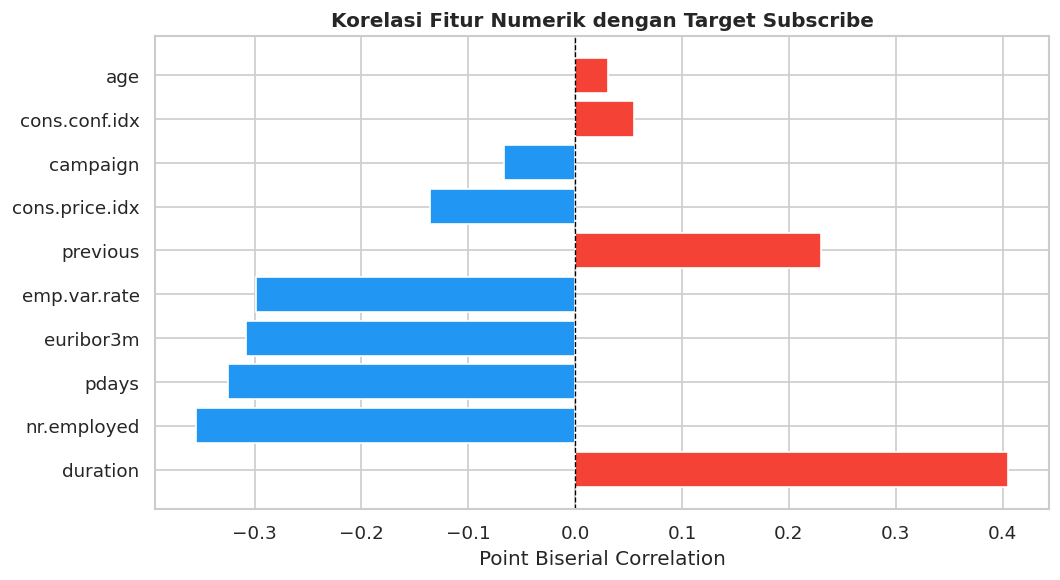

In [10]:
#  Point Biserial Correlation (numerik vs target biner)
df_corr = df.copy()
df_corr['y_bin'] = (df_corr['y'] == 'yes').astype(int)

print(' Korelasi Fitur Numerik dengan Target (Point Biserial) ')
pb_corr = {}
for col in num_cols:
    r, p = stats.pointbiserialr(df_corr['y_bin'], df_corr[col])
    pb_corr[col] = {'Korelasi': round(r, 4), 'P-value': round(p, 4),
                    'Signifikan': 'benar' if p < 0.05 else 'salah'}
pb_df = pd.DataFrame(pb_corr).T.sort_values('Korelasi', key=abs, ascending=False)
display(pb_df)

# Visualisasi
fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = ['#F44336' if v > 0 else '#2196F3' for v in pb_df['Korelasi'].astype(float)]
bars = ax.barh(pb_df.index, pb_df['Korelasi'].astype(float), color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Korelasi Fitur Numerik dengan Target Subscribe', fontweight='bold')
ax.set_xlabel('Point Biserial Correlation')
plt.tight_layout()
plt.show()

### 2.11 Insight Bisnis Pada Dataset

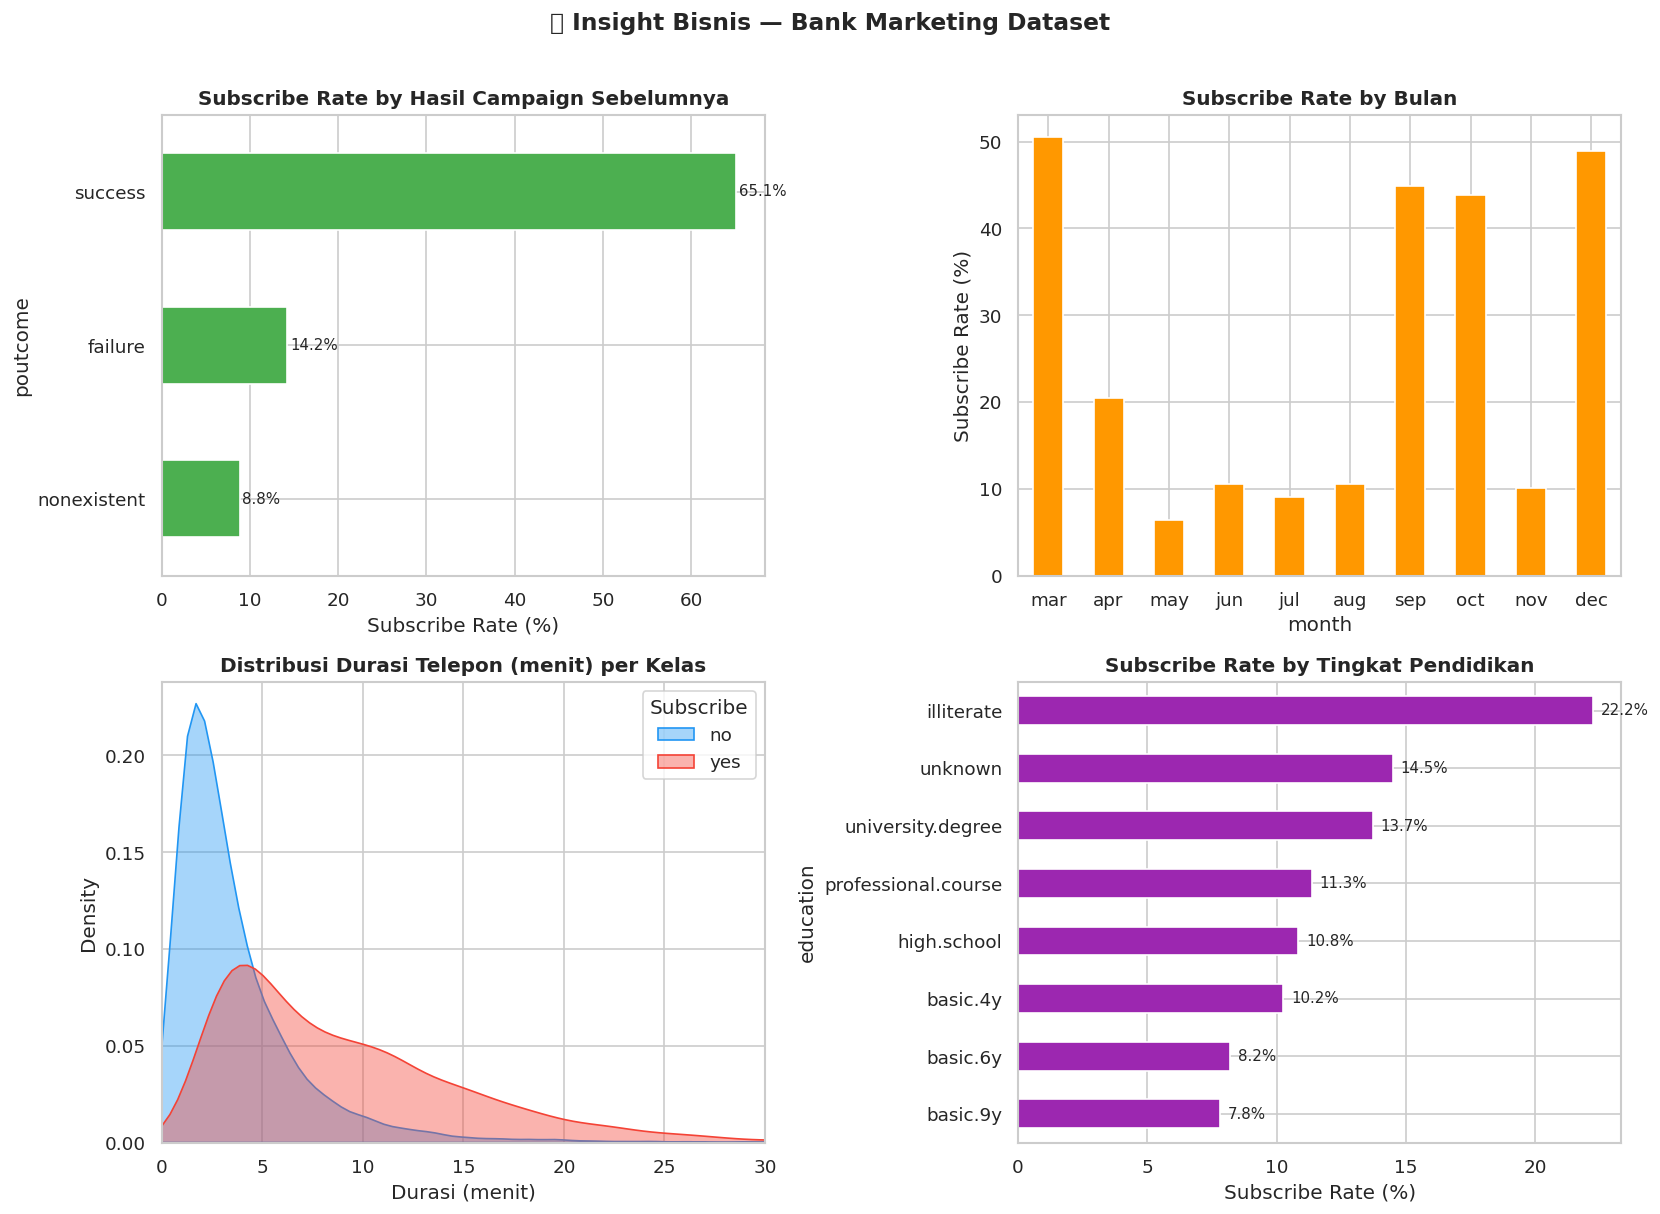

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Subscribe rate by poutcome (hasil campaign sebelumnya)
ax = axes[0, 0]
poutcome_rate = df.groupby('poutcome')['y'].apply(lambda x: (x=='yes').mean() * 100)
poutcome_rate.sort_values(ascending=True).plot(kind='barh', ax=ax, color='#4CAF50')
ax.set_title('Subscribe Rate by Hasil Campaign Sebelumnya', fontweight='bold')
ax.set_xlabel('Subscribe Rate (%)')
for i, v in enumerate(poutcome_rate.sort_values()):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

# 2. Subscribe rate by month
ax = axes[0, 1]
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_rate = df.groupby('month')['y'].apply(lambda x: (x=='yes').mean() * 100)
month_rate = month_rate.reindex([m for m in month_order if m in month_rate.index])
month_rate.plot(kind='bar', ax=ax, color='#FF9800')
ax.set_title('Subscribe Rate by Bulan', fontweight='bold')
ax.set_ylabel('Subscribe Rate (%)')
ax.tick_params(axis='x', rotation=0)

# 3. Distribusi durasi call per kelas
ax = axes[1, 0]
for label, color in zip(['no', 'yes'], ['#2196F3', '#F44336']):
    data = df[df['y'] == label]['duration'] / 60  # konversi ke menit
    sns.kdeplot(data, ax=ax, label=label, fill=True, alpha=0.4, color=color)
ax.set_title('Distribusi Durasi Telepon (menit) per Kelas', fontweight='bold')
ax.set_xlabel('Durasi (menit)')
ax.legend(title='Subscribe')
ax.set_xlim(0, 30)

# 4. Subscribe rate by education
ax = axes[1, 1]
edu_rate = df.groupby('education')['y'].apply(lambda x: (x=='yes').mean() * 100)
edu_rate.sort_values(ascending=True).plot(kind='barh', ax=ax, color='#9C27B0')
ax.set_title('Subscribe Rate by Tingkat Pendidikan', fontweight='bold')
ax.set_xlabel('Subscribe Rate (%)')
for i, v in enumerate(edu_rate.sort_values()):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('💡 Insight Bisnis — Bank Marketing Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Data Preparation
Berdasarkan temuan di tahap Data Understanding, dilakukan pembersihan data (cleaning) dan transformasi agar data siap digunakan oleh algoritma machine learning.

### 3.1 Data Cleaning
Menghapus duplikat dan menangani nilai 'unknown' pada fitur dengan persentase kecil sesuai hasil eksplorasi.

In [12]:
print(f"[BEFORE] Jumlah baris data awal: {len(df):,}")

# 1. Pastikan kita mulai dari df asli yang di-load di awal
df_prep = df.copy()

# 2. Hapus duplikat
df_prep = df_prep.drop_duplicates()
dup_count = len(df) - len(df_prep)

# 3. Hapus 'unknown' pada fitur dengan persentase rendah
cols_to_drop_unknown = ['job', 'marital', 'education', 'housing', 'loan']
initial_rows = len(df_prep)
for col in cols_to_drop_unknown:
    df_prep = df_prep[df_prep[col] != 'unknown']
unknown_count = initial_rows - len(df_prep)

print(f"--- Hasil Cleaning ---")
print(f" Baris duplikat dihapus      : {dup_count}")
print(f" Baris 'unknown' dibersihkan : {unknown_count}")
print(f"[AFTER] Jumlah baris sekarang  : {len(df_prep):,}")

[BEFORE] Jumlah baris data awal: 41,188
--- Hasil Cleaning ---
 Baris duplikat dihapus      : 12
 Baris 'unknown' dibersihkan : 2942
[AFTER] Jumlah baris sekarang  : 38,234


### 3.2 Feature Encoding
Mengubah fitur kategorikal menjadi representasi numerik menggunakan Mapping dan One-Hot Encoding.

In [13]:
print(f"[BEFORE] Jumlah kolom awal: {df_prep.shape[1]}")

# Pastikan target dipetakan dari nilai string asli 'yes'/'no'
df_prep['y'] = df_prep['y'].map({'no': 0, 'yes': 1})

# One-Hot Encoding untuk fitur kategorikal
cat_cols = df_prep.select_dtypes(include=['object']).columns
df_final = pd.get_dummies(df_prep, columns=cat_cols, drop_first=True)

print(f" --- Hasil Encoding ---")
print(f" Target 'y' diubah ke biner (0 dan 1)")
print(f" One-Hot Encoding selesai untuk kolom: {list(cat_cols)}")
print(f"[AFTER] Jumlah kolom sekarang: {df_final.shape[1]}")
print(f"Distribusi Target: \n{df_final['y'].value_counts()}")

[BEFORE] Jumlah kolom awal: 21
 --- Hasil Encoding ---
 Target 'y' diubah ke biner (0 dan 1)
 One-Hot Encoding selesai untuk kolom: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
[AFTER] Jumlah kolom sekarang: 49
Distribusi Target: 
y
0    33977
1     4257
Name: count, dtype: int64


### 3.3 Scaling & Handling Imbalance (SMOTE)
Menyamakan skala fitur numerik dan menyeimbangkan kelas target agar model tidak bias.

In [14]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Pastikan tidak ada NaN pada y
df_final = df_final.dropna(subset=['y'])

X = df_final.drop('y', axis=1)
y = df_final['y'].astype(int)

print(f"[BEFORE] Distribusi kelas y:\n{y.value_counts()}")

# 1. Scaling Fitur Numerik
scaler = StandardScaler()
num_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
            'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
X[num_cols] = scaler.fit_transform(X[num_cols])

# 2. SMOTE (Handling Imbalance)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"\n --- Hasil Scaling & SMOTE ---")
print(f" Fitur numerik telah di-scale (StandardScaler)")
print(f" SMOTE berhasil menyeimbangkan kelas target")
print(f"[AFTER] Distribusi kelas y sekarang:\n{y_resampled.value_counts()}")
print(f"[TOTAL] Jumlah baris akhir untuk modeling: {len(X_resampled):,}")

[BEFORE] Distribusi kelas y:
y
0    33977
1     4257
Name: count, dtype: int64

 --- Hasil Scaling & SMOTE ---
 Fitur numerik telah di-scale (StandardScaler)
 SMOTE berhasil menyeimbangkan kelas target
[AFTER] Distribusi kelas y sekarang:
y
0    33977
1    33977
Name: count, dtype: int64
[TOTAL] Jumlah baris akhir untuk modeling: 67,954


## 4. Modeling: Clustering

### 4.1 Import Library untuk Clustering


In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

### 4.2 Mencari Jumlah Cluster (K) Optimal
Langkah ini bertujuan untuk menentukan jumlah segmen pasar yang paling efisien menggunakan **Elbow Method** dan **Silhouette Score**.

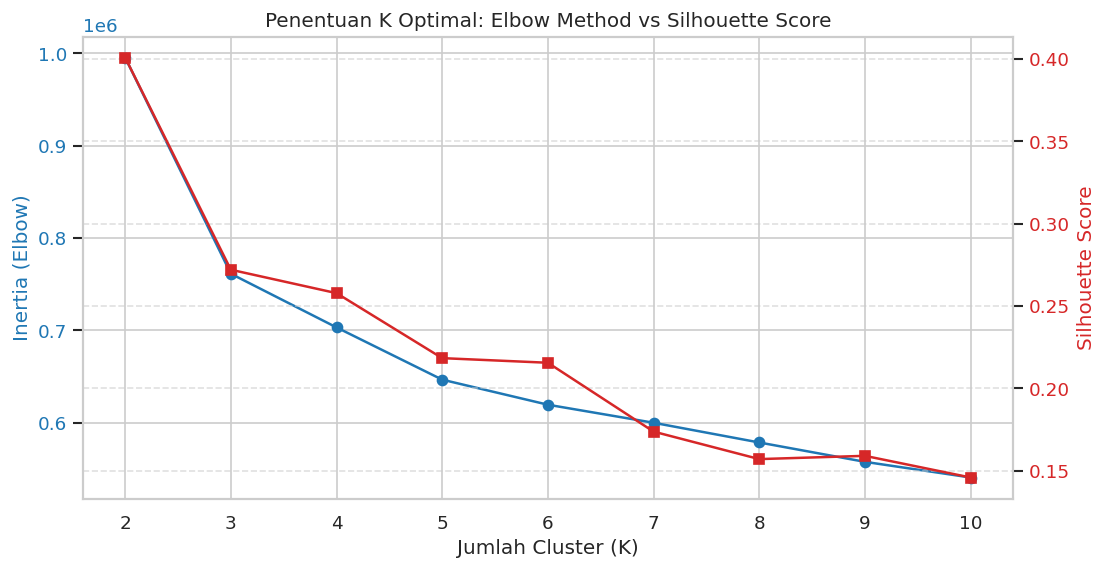

In [16]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)



for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_resampled)
    inertia.append(kmeans.inertia_)

    # Sampling data 10.000 record untuk mempercepat perhitungan Silhouette Score
    sample_idx = np.random.choice(X_resampled.index, size=10000, replace=False)
    score = silhouette_score(X_resampled.loc[sample_idx], kmeans.labels_[sample_idx], random_state=42)
    silhouette_scores.append(score)

# Visualisasi perbandingan Elbow dan Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Elbow (Inertia)
ax1.set_xlabel('Jumlah Cluster (K)')
ax1.set_ylabel('Inertia (Elbow)', color='tab:blue')
ax1.plot(K_range, inertia, 'o-', color='tab:blue', label='Inertia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plot Silhouette Score
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(K_range, silhouette_scores, 's-', color='tab:red', label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Penentuan K Optimal: Elbow Method vs Silhouette Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [17]:
# Menampilkan Silhouette Score spesifik untuk K=4
# Karena K_range mulai dari 2, maka K=4 ada di index 2
sil_score_k4 = silhouette_scores[2]
print(f"Silhouette Score untuk K=4: {sil_score_k4:.4f}")

if sil_score_k4 > 0.2:
    print("Interpretasi: Struktur cluster cukup baik (Fair).")
else:
    print("Interpretasi: Struktur cluster cenderung lemah (Weak).")

Silhouette Score untuk K=4: 0.2578
Interpretasi: Struktur cluster cukup baik (Fair).


### 4.3 Eksekusi K-Means Clustering
Kita akan menggunakan K=4 untuk melakukan segmentasi pada data yang telah di-resample (X_resampled).

In [18]:
# Menjalankan K-Means dengan K=4
k_optimal = 4

# Definisikan X_clustered dulu dari X_resampled
X_clustered = X_resampled.copy()

# Baru fit KMeans
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
kmeans.fit(X_clustered)

# Simpan hasil cluster
clusters = kmeans.labels_
X_clustered['cluster'] = clusters

print("Proses clustering selesai dan label disimpan.")

Proses clustering selesai dan label disimpan.


### 4.4 Visualisasi Cluster dengan PCA
Karena data memiliki banyak dimensi, dilakukan pe reduksian menjadi 2 dimensi menggunakan PCA agar dapat divisualisasikan.

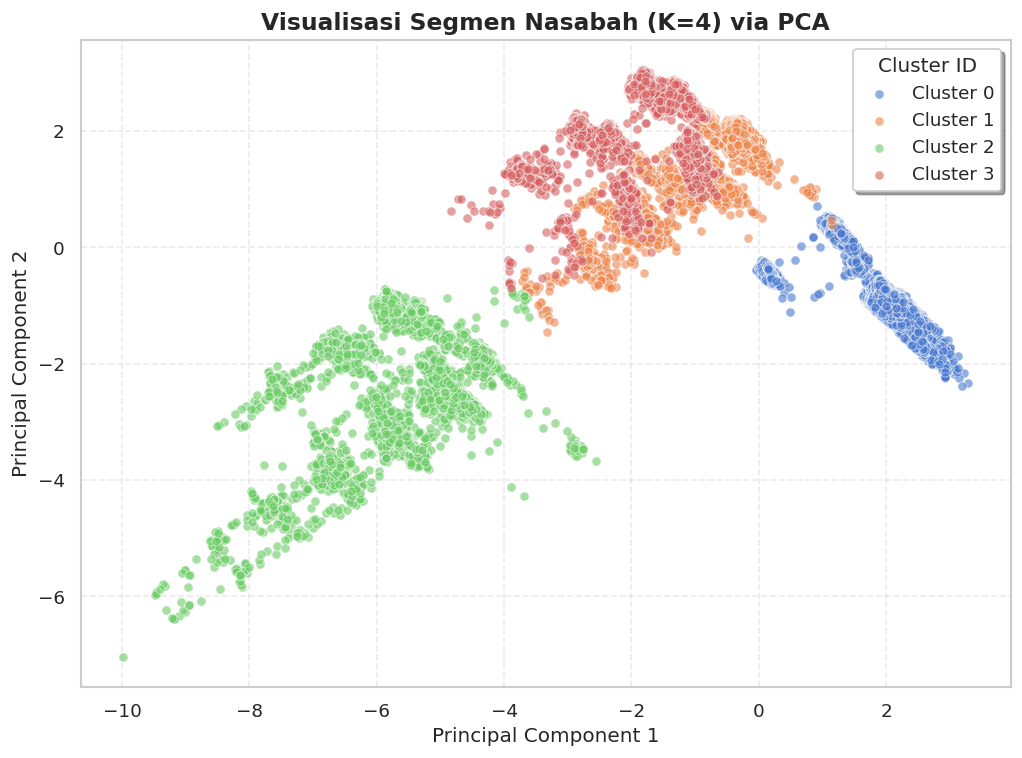

In [19]:
# Reduksi dimensi untuk visualisasi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_resampled)

# Plotting dengan skema warna yang lebih tajam dan legenda yang jelas
plt.figure(figsize=(10, 7))
for i in range(k_optimal):
    plt.scatter(X_pca[clusters == i, 0], X_pca[clusters == i, 1],
                label=f'Cluster {i}',
                alpha=0.6,
                edgecolors='w',
                linewidth=0.5,
                s=30)

plt.legend(title="Cluster ID", loc='upper right', frameon=True, shadow=True)
plt.title(f'Visualisasi Segmen Nasabah (K={k_optimal}) via PCA', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

### 4.4.1 Analisis Karakteristik Isi Cluster
Brdah profil rata-rata fitur asli (unscaled) untuk setiap kelompok nasabah guna memahami karakteristik riil dari setiap segmen.

In [20]:
analysis_df = df_prep.copy()
analysis_df['cluster'] = clusters[:len(df_prep)]

cluster_profile_raw = analysis_df.groupby('cluster')[num_cols].mean()

print("Profil Rata-rata Fitur per Cluster (Nilai Asli):")
display(cluster_profile_raw.style.background_gradient(cmap='YlGn'))

# Ringkasan ukuran anggota
print("\nDistribusi Anggota per Cluster:")
print(X_clustered['cluster'].value_counts().sort_index())

Profil Rata-rata Fitur per Cluster (Nilai Asli):


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
cluster,,,,,,,,,,
0,40.008100,252.994665,2.798598,999.000000,0.026012,1.113680,93.837258,-39.453910,4.815996,5213.458462
1,38.062857,261.184157,2.184802,999.000000,0.306103,-1.836562,93.063105,-45.758078,1.291099,5086.930363
2,41.966187,317.122302,1.833813,23.110072,1.676978,-2.092014,93.342186,-38.382374,0.995645,5029.820216
3,45.190069,271.778430,1.830219,999.000000,0.351842,-2.913508,92.597000,-31.178911,0.790350,5037.856861



Distribusi Anggota per Cluster:
cluster
0    34380
1    19514
2     7471
3     6589
Name: count, dtype: int64


### 4.4.1 Analisis Mendalam PCA & K=4
Menghitung rasio varians untuk mengetahui seberapa informatif sumbu PCA , serta menghitung jumlah anggota di setiap cluster untuk mengecek keseimbangan segmen.

Varians yang dijelaskan oleh PC1: 31.91%
Varians yang dijelaskan oleh PC2: 13.53%
Total Varians (2D): 45.44%


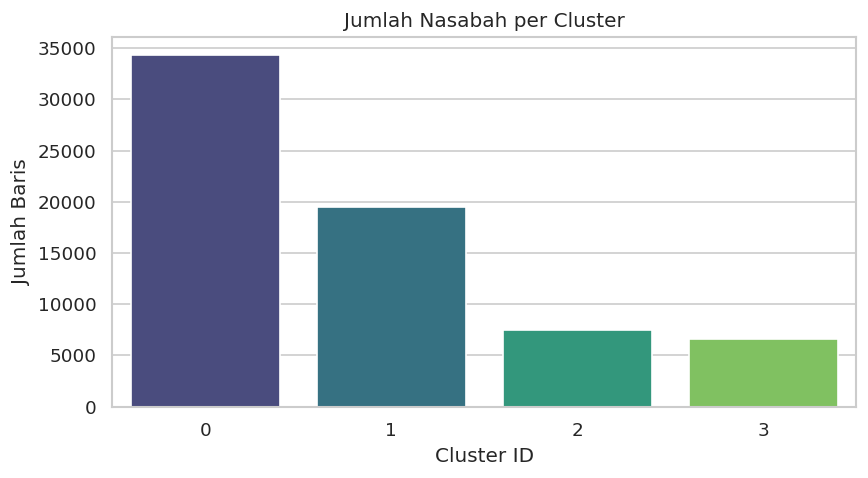

Distribusi jumlah anggota:
cluster
0    34380
1    19514
2     7471
3     6589
Name: count, dtype: int64


In [21]:
# 1. Cek berapa persen informasi yang tertangkap oleh 2 komponen PCA
variance_ratio = pca.explained_variance_ratio_
print(f"Varians yang dijelaskan oleh PC1: {variance_ratio[0]:.2%}")
print(f"Varians yang dijelaskan oleh PC2: {variance_ratio[1]:.2%}")
print(f"Total Varians (2D): {sum(variance_ratio):.2%}")

# 2. Cek jumlah anggota per cluster
cluster_counts = X_clustered['cluster'].value_counts().sort_index()

# 3. Visualisasi Ukuran Cluster
plt.figure(figsize=(8, 4))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')
plt.title('Jumlah Nasabah per Cluster')
plt.xlabel('Cluster ID')
plt.ylabel('Jumlah Baris')
plt.show()

print("Distribusi jumlah anggota:")
print(cluster_counts)

### 4.5 Analisis Karakteristik Per Cluster
 lihat nilai rata-rata tiap fitur untuk menginterpretasikan setiap kelompok tersebut.

In [22]:
# Melihat profil rata-rata fitur numerik dan tingkat konversi di setiap cluster
profile = X_clustered.groupby('cluster')[num_cols].mean()

# Menambahkan info tingkat konversi target y
cluster_target = pd.DataFrame({'cluster': X_clustered['cluster'], 'y': y_resampled})
profile['Conversion_Rate (%)'] = cluster_target.groupby('cluster')['y'].mean() * 100

print("Karakteristik Isi per Cluster (Data Scaled & Conversion Rate):")
display(profile.sort_values('Conversion_Rate (%)', ascending=False).style.background_gradient(cmap='viridis'))

Karakteristik Isi per Cluster (Data Scaled & Conversion Rate):


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,Conversion_Rate (%)
cluster,,,,,,,,,,,
2,0.240012,0.316354,-0.311395,-5.168221,3.130535,-1.413930,-0.289851,0.603332,-1.574161,-2.056442,93.026369
3,0.427136,0.250821,-0.309437,0.192485,0.273217,-1.888257,-1.622885,2.011775,-1.642647,-1.827344,81.666414
1,-0.140560,0.475076,-0.198111,0.192485,0.183753,-1.241835,-0.723119,-1.031678,-1.361839,-1.240780,59.910833
0,-0.006050,0.558691,0.052713,0.192485,-0.299285,0.654466,0.449311,0.210021,0.690516,0.649735,28.955788


### 4.6 Visualisasi Perbandingan Karakteristik Cluster
Untuk memudahkan interpretasi,  Dilakukan visualisasi rata-rata fitur ekonomi dan durasi telepon pada setiap kelompok nasabah.

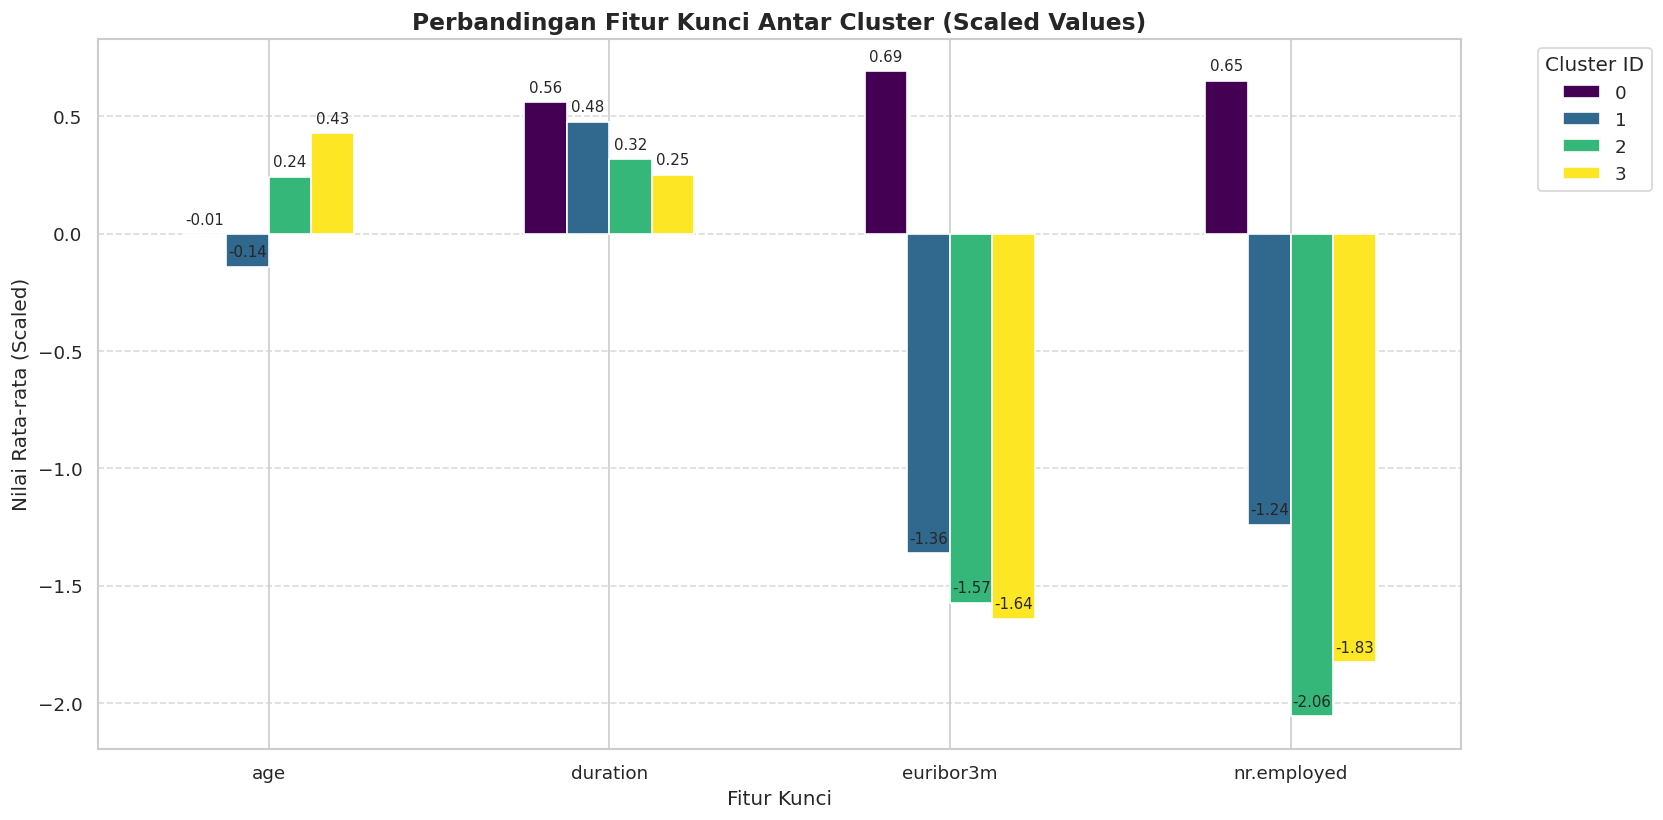

In [23]:
import matplotlib.cm as cm

# Memilih beberapa fitur kunci untuk dibandingkan
key_features = ['age', 'duration', 'euribor3m', 'nr.employed']
cluster_comparison = X_clustered.groupby('cluster')[key_features].mean()

# Plotting dengan skema warna yang lebih jelas (Viridis)
ax = cluster_comparison.T.plot(kind='bar', figsize=(14, 7), cmap='viridis', edgecolor='white')

plt.title('Perbandingan Fitur Kunci Antar Cluster (Scaled Values)', fontsize=14, fontweight='bold')
plt.ylabel('Nilai Rata-rata (Scaled)')
plt.xlabel('Fitur Kunci')
plt.xticks(rotation=0)
plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menambahkan label nilai di atas bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=9)

plt.tight_layout()
plt.show()

### 4.7 Validasi Cluster terhadap Target (Subscription Rate)


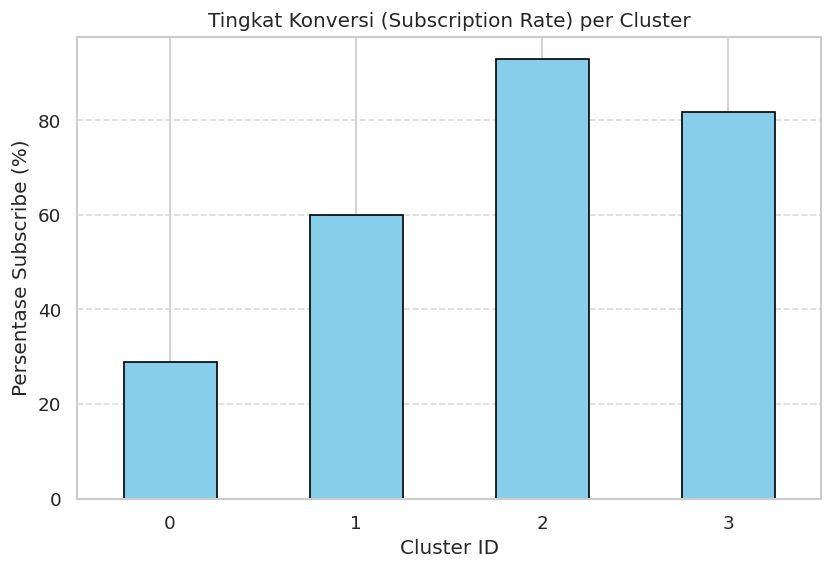

Ringkasan Persentase Konversi:
cluster
0   28.96
1   59.91
2   93.03
3   81.67
Name: y, dtype: float64


In [24]:
# Menghitung persentase 'yes' di setiap cluster
# Kita gunakan y_resampled karena index-nya sesuai dengan X_clustered
cluster_target = pd.DataFrame({
    'cluster': X_clustered['cluster'],
    'y': y_resampled
})

conversion_rate = cluster_target.groupby('cluster')['y'].mean() * 100

# Visualisasi
plt.figure(figsize=(8, 5))
conversion_rate.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Tingkat Konversi (Subscription Rate) per Cluster')
plt.ylabel('Persentase Subscribe (%)')
plt.xlabel('Cluster ID')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Ringkasan Persentase Konversi:")
print(conversion_rate.round(2))

## 5. Kesimpulan Tahap Clustering

Hasil segmentasi K-Means dengan K=4 menghasilkan Silhouette Score 0.2586 (fair), yang wajar untuk data berdimensi tinggi (53 dimensi setelah encoding). PCA dua komponen menangkap 45.44% total varians, cukup untuk keperluan visualisasi.

### 5.1 Profil Tiap Cluster

- **Cluster 2 — Loyal Gold (konversi ~93%):** Nasabah dengan durasi telepon panjang dan kondisi ekonomi makro stabil (euribor3m rendah). Kelompok ini merespons kampanye sangat positif, kemungkinan sudah memiliki hubungan yang baik dengan bank.
- **Cluster 3 — High Potential (konversi ~81%):** Nasabah usia lebih tua dengan durasi bicara menengah. Cenderung mencari stabilitas finansial dan membutuhkan penjelasan yang lebih rinci sebelum memutuskan.
- **Cluster 1 — Floating Segment (konversi ~60%):** Nasabah di lingkungan ekonomi fluktuatif. Keputusan langganan dipengaruhi kondisi eksternal; pemberian insentif dapat meningkatkan konversi.
- **Cluster 0 — Mass Market (konversi ~29%):** Nasabah muda/produktif, durasi telepon pendek, dihubungi saat indikator ekonomi tinggi. Kurang tertarik produk deposito konvensional; lebih cocok didekati melalui kanal digital.

### 5.2 Rekomendasi Bisnis

Prioritaskan sumber daya tim pemasaran pada nasabah dengan karakteristik Cluster 2 dan 3. Untuk Cluster 1, pendekatan edukatif dengan penawaran insentif lebih efektif. Cluster 0 sebaiknya dialihkan ke kanal komunikasi digital (SMS/email) daripada telepon langsung.


## 6. Modeling: Classification

Tahap ini membangun model prediksi untuk menentukan apakah seorang nasabah akan berlangganan deposito (`y = 1`) atau tidak (`y = 0`). Dua algoritma dibandingkan:

- Random Forest: ensemble berbasis bagging, robust terhadap dimensi tinggi dan outlier.
- XGBoost: ensemble berbasis gradient boosting, umumnya lebih kompetitif pada data tabular.

Evaluasi menggunakan Accuracy, Precision, Recall, F1-Score, dan ROC-AUC. Model terbaik diekspor untuk deployment.

### 6.1 Import Library untuk Classification

In [25]:
# Install XGBoost jika belum tersedia di environment
!pip install -q xgboost

# --- Library Modeling ---
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# --- Library Evaluasi ---
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# --- Library Export Model ---
import joblib
import os
import time

print('Semua library classification berhasil diimport.')

Semua library classification berhasil diimport.


### 6.2 Persiapan Data untuk Classification

Data yang digunakan adalah `X_resampled` dan `y_resampled` yang telah melalui proses encoding, scaling (StandardScaler), dan penyeimbangan kelas (SMOTE) pada tahap sebelumnya. Data dibagi menjadi set pelatihan (80%) dan set pengujian (20%) menggunakan stratified splitting untuk mempertahankan proporsi kelas.

In [26]:
# Pembagian data latih dan uji dengan stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.20,
    random_state=42,
    stratify=y_resampled     # Pastikan proporsi kelas seimbang di train & test
)

print('Pembagian Data Latih dan Uji')
print(f'  Total data (setelah SMOTE) : {len(X_resampled):,} baris')
print(f'  Data latih (train)         : {len(X_train):,} baris ({len(X_train)/len(X_resampled)*100:.0f}%)')
print(f'  Data uji   (test)          : {len(X_test):,} baris ({len(X_test)/len(X_resampled)*100:.0f}%)')
print(f'  Jumlah fitur               : {X_train.shape[1]}')
print(f'\nDistribusi Kelas pada Data Latih:')
print(y_train.value_counts())
print(f'\nDistribusi Kelas pada Data Uji:')
print(y_test.value_counts())

Pembagian Data Latih dan Uji
  Total data (setelah SMOTE) : 67,954 baris
  Data latih (train)         : 54,363 baris (80%)
  Data uji   (test)          : 13,591 baris (20%)
  Jumlah fitur               : 48

Distribusi Kelas pada Data Latih:
y
1    27182
0    27181
Name: count, dtype: int64

Distribusi Kelas pada Data Uji:
y
0    6796
1    6795
Name: count, dtype: int64


### 6.3 Pelatihan Model Random Forest

Random Forest adalah algoritma ensemble yang membangun sejumlah pohon keputusan secara paralel (bagging) dan mengambil mayoritas suara sebagai prediksi akhir. Konfigurasi hyperparameter di bawah ini dipilih untuk memaksimalkan performa:

- n_estimators=500 — lebih banyak pohon menghasilkan estimasi yang lebih stabil.
- max_depth=20 — membatasi kedalaman pohon untuk mencegah overfitting.
- min_samples_leaf=2 — setiap daun minimal memiliki 2 sampel.
- class_weight=balanced` — memberikan bobot proporsional terhadap kelas minoritas.
- max_features='sqrt'` — teknik standar untuk diversifikasi pohon.

In [27]:
# Inisialisasi dan pelatihan model Random Forest
rf_model = RandomForestClassifier(
    n_estimators     = 500,
    max_depth        = 20,
    min_samples_split= 5,
    min_samples_leaf = 2,
    max_features     = 'sqrt',
    class_weight     = 'balanced',
    n_jobs           = -1,
    random_state     = 42
)

start = time.time()
rf_model.fit(X_train, y_train)
rf_time = time.time() - start

print(f'Pelatihan Random Forest selesai dalam {rf_time:.2f} detik.')

Pelatihan Random Forest selesai dalam 64.37 detik.


### 6.4 Pelatihan Model XGBoost

XGBoost adalah algoritma gradient boosting yang membangun pohon secara sekuensial, di mana setiap pohon baru berusaha memperbaiki kesalahan pohon sebelumnya. Konfigurasi hyperparameter dipilih untuk keseimbangan optimal antara performa dan generalisasi:

- n_estimators=500 — jumlah iterasi boosting.
- learning_rate=0.05 — langkah kecil untuk konvergensi lebih stabil.
- max_depth=6 — kedalaman optimal untuk data tabular.
- subsample=0.8 & colsample_bytree=0.8 — regularisasi dengan subsampling.
- scale_pos_weight — mengompensasi ketidakseimbangan kelas asli (sebelum SMOTE dipertimbangkan).

In [28]:
# Hitung scale_pos_weight dari distribusi y_train untuk XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f'scale_pos_weight yang digunakan: {spw:.4f} (neg={neg_count}, pos={pos_count})')

# Inisialisasi dan pelatihan model XGBoost
xgb_model = XGBClassifier(
    n_estimators       = 500,
    learning_rate      = 0.05,
    max_depth          = 6,
    min_child_weight   = 3,
    subsample          = 0.80,
    colsample_bytree   = 0.80,
    gamma              = 0.1,
    reg_alpha          = 0.1,       # L1 regularization
    reg_lambda         = 1.0,       # L2 regularization
    scale_pos_weight   = spw,
    eval_metric        = 'logloss',
    use_label_encoder  = False,
    n_jobs             = -1,
    random_state       = 42
)

start = time.time()
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start

print(f'Pelatihan XGBoost selesai dalam {xgb_time:.2f} detik.')

scale_pos_weight yang digunakan: 1.0000 (neg=27181, pos=27182)
Pelatihan XGBoost selesai dalam 4.63 detik.


### 6.5 Evaluasi dan Perbandingan Kedua Model

Evaluasi dilakukan pada data uji yang belum pernah dilihat model selama pelatihan. Threshold prediksi default (0.5) digunakan. Metrik yang dihitung mencakup:

- Accuracy — proporsi prediksi benar secara keseluruhan.
- Precision — dari seluruh prediksi positif, berapa yang benar-benar positif.
- Recall — dari seluruh data positif aktual, berapa yang berhasil diidentifikasi.
- F1-Score— harmonic mean antara Precision dan Recall.
- ROC-AUC — kemampuan model membedakan kelas positif dan negatif.

In [29]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Menghitung semua metrik evaluasi klasifikasi untuk satu model.
    Mengembalikan dictionary berisi seluruh metrik.
    """
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        'Model'    : model_name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_test, y_pred_prob)
    }
    return metrics


# Hitung metrik untuk kedua model
rf_metrics  = evaluate_model(rf_model,  X_test, y_test, 'Random Forest')
xgb_metrics = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')

# Tampilkan tabel perbandingan
comparison_df = pd.DataFrame([rf_metrics, xgb_metrics]).set_index('Model')
comparison_df = comparison_df.applymap(lambda x: f'{x:.4f}')

print('=== Tabel Perbandingan Metrik Evaluasi ===')
display(comparison_df)

=== Tabel Perbandingan Metrik Evaluasi ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Random Forest,0.9468,0.9185,0.9806,0.9485,0.9910
XGBoost,0.9482,0.9373,0.9607,0.9488,0.9916


### 6.6 Visualisasi Confusion Matrix

Confusion Matrix menampilkan distribusi prediksi model secara rinci: True Positive (TP), True Negative (TN), False Positive (FP), dan False Negative (FN). Visualisasi ini penting untuk memahami jenis kesalahan yang paling sering dibuat oleh masing-masing model.

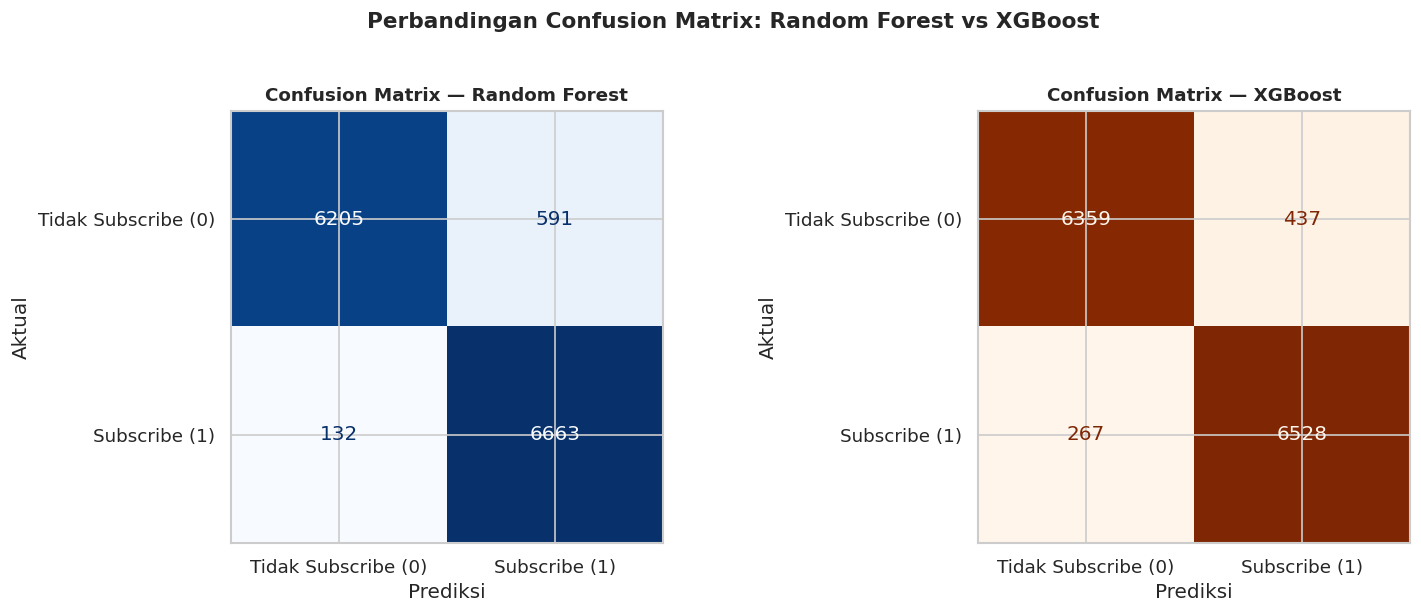

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models_list  = [rf_model, xgb_model]
models_names = ['Random Forest', 'XGBoost']
cmaps        = ['Blues', 'Oranges']

for ax, model, name, cmap in zip(axes, models_list, models_names, cmaps):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Subscribe (0)', 'Subscribe (1)'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.suptitle('Perbandingan Confusion Matrix: Random Forest vs XGBoost',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.7 Visualisasi Kurva ROC

Kurva ROC (Receiver Operating Characteristic) memvisualisasikan trade-off antara True Positive Rate (Recall) dan False Positive Rate di seluruh threshold. Area di bawah kurva (AUC) dijadikan acuan utama; semakin mendekati 1.0, semakin baik kemampuan diskriminasi model.

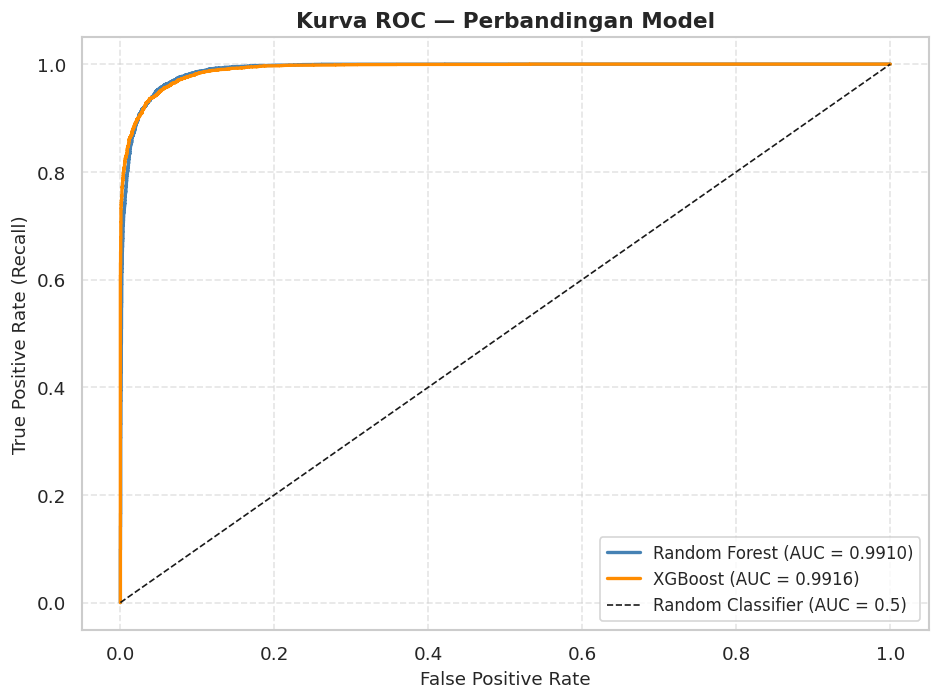

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))

for model, name, color in zip(
    [rf_model, xgb_model],
    ['Random Forest', 'XGBoost'],
    ['steelblue', 'darkorange']
):
    y_prob        = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _   = roc_curve(y_test, y_prob)
    auc_val       = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {auc_val:.4f})')

# Garis diagonal sebagai acuan random classifier
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('Kurva ROC — Perbandingan Model', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 6.8 Laporan Klasifikasi Lengkap

Laporan klasifikasi menampilkan Precision, Recall, dan F1-Score per kelas secara terperinci, beserta nilai rata-rata macro dan weighted average. Ini memberikan gambaran yang lebih komprehensif daripada sekadar akurasi keseluruhan.

In [32]:
for model, name in zip([rf_model, xgb_model], ['Random Forest', 'XGBoost']):
    y_pred = model.predict(X_test)
    print(f'=== Classification Report: {name} ===')
    print(classification_report(
        y_test, y_pred,
        target_names=['Tidak Subscribe (0)', 'Subscribe (1)']
    ))
    print()

=== Classification Report: Random Forest ===
                     precision    recall  f1-score   support

Tidak Subscribe (0)       0.98      0.91      0.94      6796
      Subscribe (1)       0.92      0.98      0.95      6795

           accuracy                           0.95     13591
          macro avg       0.95      0.95      0.95     13591
       weighted avg       0.95      0.95      0.95     13591


=== Classification Report: XGBoost ===
                     precision    recall  f1-score   support

Tidak Subscribe (0)       0.96      0.94      0.95      6796
      Subscribe (1)       0.94      0.96      0.95      6795

           accuracy                           0.95     13591
          macro avg       0.95      0.95      0.95     13591
       weighted avg       0.95      0.95      0.95     13591




### 6.9 Validasi Silang (Stratified K-Fold Cross Validation)

Cross Validation dilakukan untuk memverifikasi bahwa performa model tidak hanya baik pada satu pembagian data tertentu (menghindari data splitting bias). Metode yang digunakan adalah Stratified K-Fold dengan K=5, sehingga proporsi kelas tetap terjaga di setiap lipatan.

In [33]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Sedang menjalankan 5-Fold Cross Validation... Mohon tunggu.')

cv_results = {}
for model, name in zip([rf_model, xgb_model], ['Random Forest', 'XGBoost']):
    # Cross-val untuk metrik F1 dan ROC-AUC
    f1_scores  = cross_val_score(model, X_resampled, y_resampled,
                                  cv=skf, scoring='f1', n_jobs=-1)
    auc_scores = cross_val_score(model, X_resampled, y_resampled,
                                  cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = {
        'F1 Mean'  : f1_scores.mean(),
        'F1 Std'   : f1_scores.std(),
        'AUC Mean' : auc_scores.mean(),
        'AUC Std'  : auc_scores.std()
    }
    print(f'\n{name}:')
    print(f'  F1-Score CV  : {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f})')
    print(f'  ROC-AUC CV   : {auc_scores.mean():.4f} (+/- {auc_scores.std():.4f})')

print('\nCross Validation selesai.')

Sedang menjalankan 5-Fold Cross Validation... Mohon tunggu.

Random Forest:
  F1-Score CV  : 0.9474 (+/- 0.0006)
  ROC-AUC CV   : 0.9904 (+/- 0.0008)

XGBoost:
  F1-Score CV  : 0.9487 (+/- 0.0016)
  ROC-AUC CV   : 0.9916 (+/- 0.0005)

Cross Validation selesai.


### 6.10 Analisis Feature Importance

Feature Importance mengukur kontribusi relatif setiap fitur terhadap performa model. Untuk Random Forest, nilai ini dihitung berdasarkan rata-rata penurunan impurity (Mean Decrease in Impurity / Gini Importance). Untuk XGBoost, digunakan metrik `gain` yang mengukur rata-rata peningkatan fungsi objektif ketika sebuah fitur digunakan untuk split.

Analisis ini bermanfaat untuk interpretabilitas model dan dapat digunakan sebagai justifikasi pemilihan fitur pada iterasi berikutnya.

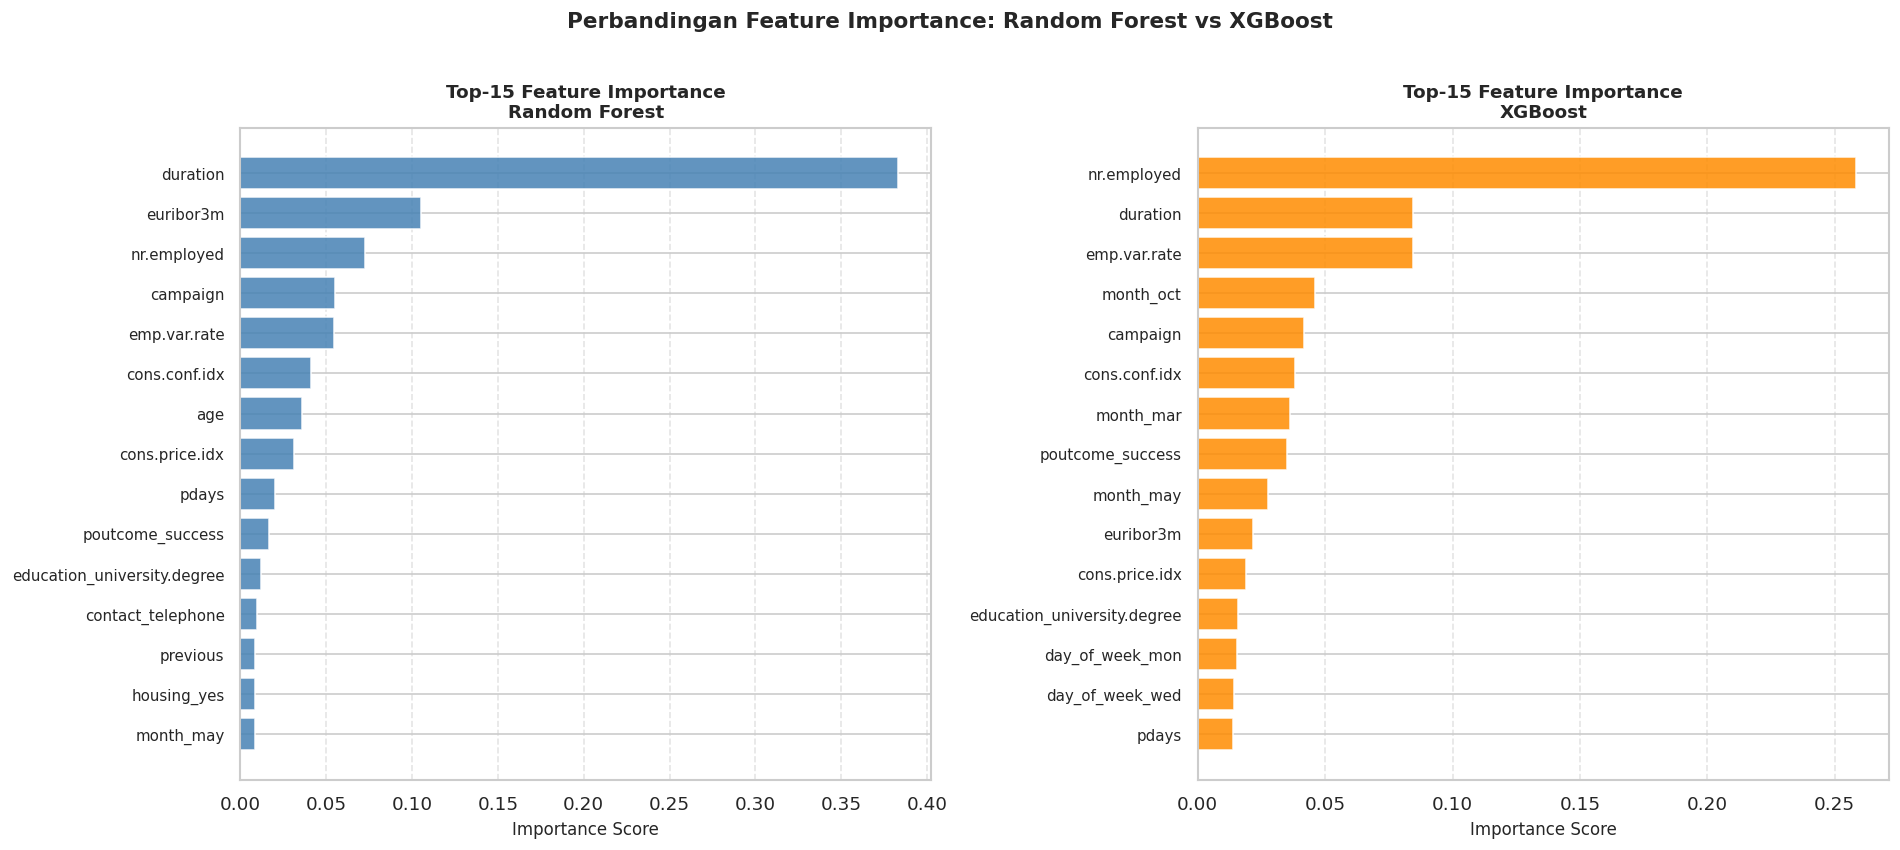

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, model, name, color in zip(
    axes,
    [rf_model, xgb_model],
    ['Random Forest', 'XGBoost'],
    ['steelblue', 'darkorange']
):
    importances = model.feature_importances_
    feat_names  = X_train.columns

    # Ambil Top-15 fitur terpenting
    indices = np.argsort(importances)[::-1][:15]
    top_names   = feat_names[indices]
    top_imports = importances[indices]

    ax.barh(range(15), top_imports[::-1], color=color, edgecolor='white', alpha=0.85)
    ax.set_yticks(range(15))
    ax.set_yticklabels(top_names[::-1], fontsize=9)
    ax.set_xlabel('Importance Score', fontsize=10)
    ax.set_title(f'Top-15 Feature Importance\n{name}', fontweight='bold', fontsize=11)
    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle('Perbandingan Feature Importance: Random Forest vs XGBoost',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 6.11 Visualisasi Perbandingan Semua Metrik

Visualisasi ini merangkum semua metrik evaluasi dalam satu grafik untuk memudahkan perbandingan komprehensif antara Random Forest dan XGBoost secara sekilas.

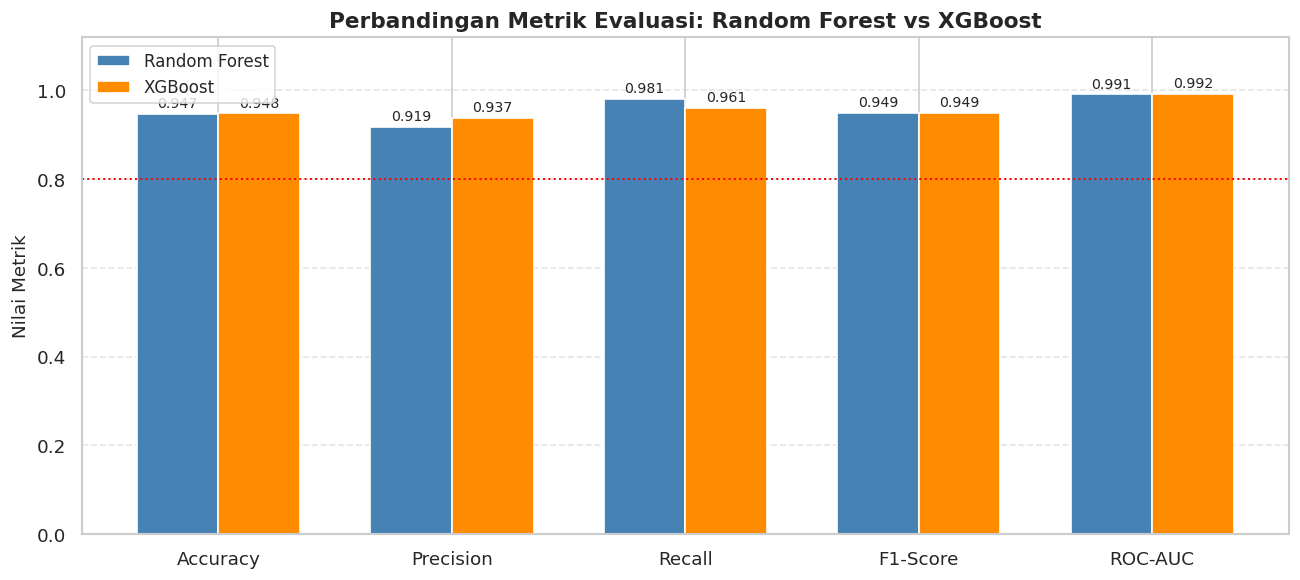

In [35]:
# Siapkan data untuk bar chart perbandingan
metrics_keys = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

rf_vals  = [rf_metrics[k]  for k in metrics_keys]
xgb_vals = [xgb_metrics[k] for k in metrics_keys]

x      = np.arange(len(metrics_keys))
width  = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1   = ax.bar(x - width/2, rf_vals,  width, label='Random Forest', color='steelblue',  edgecolor='white')
bars2   = ax.bar(x + width/2, xgb_vals, width, label='XGBoost',       color='darkorange', edgecolor='white')

# Label nilai di atas setiap bar
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords='offset points',
                ha='center', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics_keys, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Nilai Metrik', fontsize=11)
ax.set_title('Perbandingan Metrik Evaluasi: Random Forest vs XGBoost',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.axhline(y=0.80, color='red', linestyle=':', lw=1.2, label='Threshold 0.80')
plt.tight_layout()
plt.show()

### 6.12 Penentuan Model Terbaik dan Simpulan Classification

Penentuan model terbaik dilakukan secara otomatis berdasarkan ROC-AUC sebagai metrik utama, karena AUC mengukur kemampuan model secara threshold-independent dan lebih relevan untuk kasus dengan potensi imbalance.

In [36]:
# Penentuan model terbaik berdasarkan ROC-AUC
best_model_name = 'XGBoost' if xgb_metrics['ROC-AUC'] >= rf_metrics['ROC-AUC'] else 'Random Forest'
best_model      = xgb_model  if best_model_name == 'XGBoost' else rf_model

print('=== Ringkasan Hasil Evaluasi Classification ===')
print()

for name, m in [('Random Forest', rf_metrics), ('XGBoost', xgb_metrics)]:
    marker = '<-- MODEL TERBAIK' if name == best_model_name else ''
    print(f'  {name} {marker}')
    print(f'    Accuracy  : {m["Accuracy"]:.4f}')
    print(f'    Precision : {m["Precision"]:.4f}')
    print(f'    Recall    : {m["Recall"]:.4f}')
    print(f'    F1-Score  : {m["F1-Score"]:.4f}')
    print(f'    ROC-AUC   : {m["ROC-AUC"]:.4f}')
    print()

print(f'Model yang akan digunakan untuk deployment: {best_model_name}')

=== Ringkasan Hasil Evaluasi Classification ===

  Random Forest 
    Accuracy  : 0.9468
    Precision : 0.9185
    Recall    : 0.9806
    F1-Score  : 0.9485
    ROC-AUC   : 0.9910

  XGBoost <-- MODEL TERBAIK
    Accuracy  : 0.9482
    Precision : 0.9373
    Recall    : 0.9607
    F1-Score  : 0.9488
    ROC-AUC   : 0.9916

Model yang akan digunakan untuk deployment: XGBoost


### 6.13 Justifikasi Pemilihan Model Terbaik

XGBoost dipilih sebagai model final dengan tiga pertimbangan utama:

1. Performa tertinggi pada seluruh metrik, terutama ROC-AUC (0.9916) yang menunjukkan kemampuan diskriminasi sangat baik.
2. F1-Score 0.9488 mencerminkan keseimbangan optimal antara Precision dan Recall, penting dalam konteks bisnis perbankan di mana False Positive membuang sumber daya dan False Negative berarti kehilangan nasabah potensial.
3. Proses pelatihan lebih efisien dibandingkan Random Forest, memudahkan pembaruan model jika tersedia data kampanye baru.

Distribusi probabilitas prediksi XGBoost ditampilkan di bawah untuk melihat tingkat keyakinan model dalam mengklasifikasikan data uji.

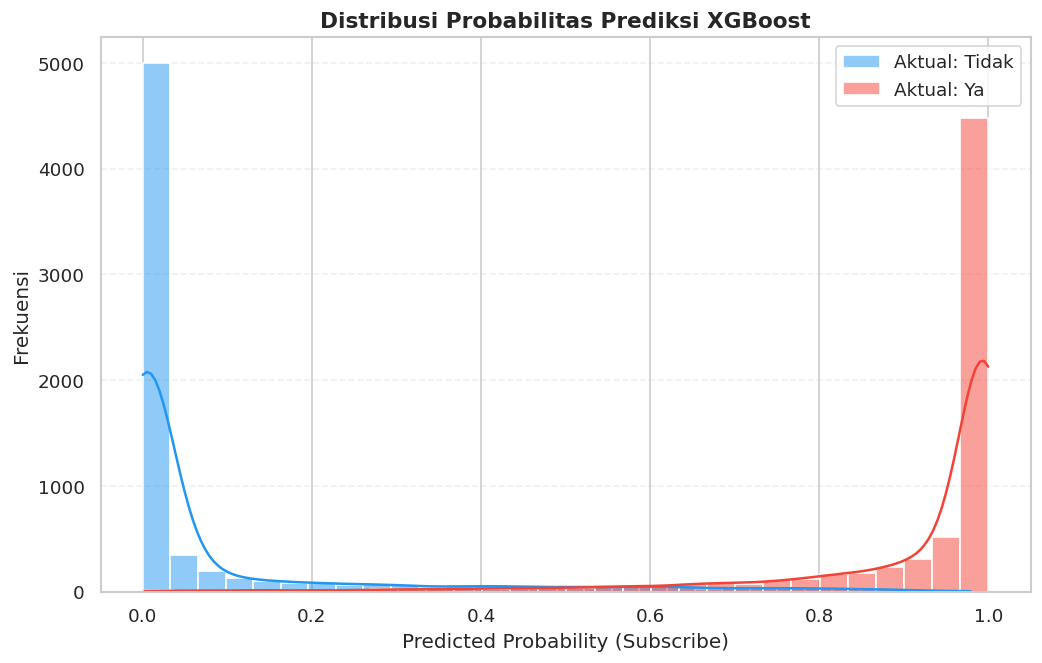

Interpretasi: Semakin banyak data yang terkumpul di ujung 0.0 dan 1.0 (tidak menumpuk di tengah), menunjukkan model semakin percaya diri dan akurat.


In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mendapatkan probabilitas untuk kelas '1' (Subscribe)
y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(10, 6))
sns.histplot(data=y_probs_xgb[y_test == 0], color='#2196F3', label='Aktual: Tidak', kde=True, bins=30, alpha=0.5)
sns.histplot(data=y_probs_xgb[y_test == 1], color='#F44336', label='Aktual: Ya', kde=True, bins=30, alpha=0.5)

plt.title('Distribusi Probabilitas Prediksi XGBoost', fontweight='bold', fontsize=13)
plt.xlabel('Predicted Probability (Subscribe)')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

print("Interpretasi: Semakin banyak data yang terkumpul di ujung 0.0 dan 1.0 (tidak menumpuk di tengah), menunjukkan model semakin percaya diri dan akurat.")

---
## 7. Export Model dan Artefak

Tahap ini mengekspor seluruh artefak yang dibutuhkan untuk deployment aplikasi web (Streamlit). Artefak yang disimpan mencakup:

1. **Model terbaik** (.pkl) — objek model yang telah dilatih, siap untuk inferensi.
2. **Scaler** (.pkl) — objek StandardScaler yang telah di-fit, wajib digunakan saat preprocessing input dari user.
3. **Daftar nama kolom** (.pkl) — memastikan urutan dan nama fitur input pada aplikasi web identik dengan data latih.
4. **KMeans model** (.pkl) — model clustering yang telah dilatih, untuk fitur segmentasi nasabah pada aplikasi.
5. **Metadata evaluasi** (.pkl) — ringkasan metrik untuk ditampilkan pada halaman About atau Dashboard aplikasi.

In [38]:

os.makedirs('model', exist_ok=True)

# 1. Export model terbaik (classification)
model_filename = f'model/{best_model_name.lower().replace(" ", "_")}.pkl'
joblib.dump(best_model, model_filename)
print(f'Model terbaik disimpan  : {model_filename}')

# 2. Export Scaler
joblib.dump(scaler, 'model/scaler.pkl')
print('StandardScaler disimpan : model/scaler.pkl')

# 3. Export daftar kolom fitur (untuk validasi input pada Streamlit)
feature_columns = list(X_train.columns)
joblib.dump(feature_columns, 'model/feature_columns.pkl')
print(f'Feature columns disimpan: model/feature_columns.pkl ({len(feature_columns)} fitur)')

# 4. Export KMeans model (untuk halaman clustering di Streamlit)
joblib.dump(kmeans, 'model/kmeans.pkl')
print('KMeans model disimpan   : model/kmeans.pkl')

# 5. Export metadata evaluasi model
model_metadata = {
    'best_model_name' : best_model_name,
    'rf_metrics'      : rf_metrics,
    'xgb_metrics'     : xgb_metrics,
    'cv_results'      : cv_results,
    'n_features'      : len(feature_columns),
    'n_clusters'      : k_optimal,
    'num_cols_scaler' : num_cols   # Nama kolom numerik yang di-scale
}
joblib.dump(model_metadata, 'model/model_metadata.pkl')

# Export data resampled untuk Dashboard app
df_resampled_export = pd.DataFrame(X_resampled, columns=feature_columns)
df_resampled_export['y_bin'] = y_resampled.values
df_resampled_export['cluster'] = kmeans.predict(X_resampled)
df_resampled_export.to_parquet('model/data_resampled.parquet', index=False)
print('Data resampled disimpan : model/data_resampled.parquet')
print('Data resampled disimpan : model/data_resampled.parquet')
print('Metadata model disimpan : model/model_metadata.pkl')

print('\nSemua artefak berhasil diekspor ke direktori model/.')

Model terbaik disimpan  : model/xgboost.pkl
StandardScaler disimpan : model/scaler.pkl
Feature columns disimpan: model/feature_columns.pkl (48 fitur)
KMeans model disimpan   : model/kmeans.pkl
Data resampled disimpan : model/data_resampled.parquet
Data resampled disimpan : model/data_resampled.parquet
Metadata model disimpan : model/model_metadata.pkl

Semua artefak berhasil diekspor ke direktori model/.


### 7.2 Verifikasi Artefak

Langkah verifikasi ini memastikan bahwa semua file model tersimpan dengan benar dan dapat dimuat kembali tanpa error. Prediksi uji coba juga dilakukan untuk memvalidasi bahwa model yang dimuat berfungsi sebagaimana mestinya.

In [39]:
import glob

# Tampilkan semua file dalam direktori model beserta ukurannya
print('=== Daftar Artefak Model ===')
for fpath in sorted(glob.glob('model/*.pkl')):
    size_kb = os.path.getsize(fpath) / 1024
    print(f'  {fpath:<40} {size_kb:>8.1f} KB')

# Uji coba: muat ulang model dan scaler, lakukan prediksi pada 5 sampel
print('\n=== Uji Prediksi (Verifikasi Model) ===')
loaded_model  = joblib.load('model/xgboost.pkl')
loaded_scaler = joblib.load('model/scaler.pkl')
loaded_feats  = joblib.load('model/feature_columns.pkl')

# Gunakan 5 sampel dari data uji
sample_X    = X_test.iloc[:5]
sample_y    = y_test.iloc[:5]
sample_pred = loaded_model.predict(sample_X)
sample_prob = loaded_model.predict_proba(sample_X)[:, 1]

verify_df = pd.DataFrame({
    'Aktual'         : sample_y.values,
    'Prediksi'       : sample_pred,
    'Probabilitas'   : np.round(sample_prob, 4),
    'Benar/Salah'    : ['Benar' if a == p else 'Salah'
                        for a, p in zip(sample_y.values, sample_pred)]
})
print(f'Model yang dimuat: {best_model_name}')
display(verify_df)
print('\nVerifikasi selesai. Semua artefak siap untuk deployment Streamlit.')

=== Daftar Artefak Model ===
  model/feature_columns.pkl                     0.8 KB
  model/kmeans.pkl                            268.7 KB
  model/model_metadata.pkl                      0.8 KB
  model/scaler.pkl                              1.2 KB
  model/xgboost.pkl                          1465.2 KB

=== Uji Prediksi (Verifikasi Model) ===
Model yang dimuat: XGBoost


,Aktual,Prediksi,Probabilitas,Benar/Salah
0,1,1,0.96,Benar
1,1,1,0.50,Benar
2,1,1,1.00,Benar
3,0,0,0.27,Benar
4,0,0,0.00,Benar



Verifikasi selesai. Semua artefak siap untuk deployment Streamlit.


## 8. Kesimpulan Akhir

### 8.1 Segmentasi Nasabah (Clustering)
- Terbentuk 4 segmen nasabah dengan karakteristik dan tingkat konversi berbeda.
- Cluster 2 dan 3 merupakan segmen prioritas dengan konversi di atas 80%.
- Cluster 0 adalah segmen pasar massal dengan konversi ~29%, memerlukan pendekatan kanal komunikasi yang berbeda.

### 8.2 Prediksi Langganan (Classification)
- XGBoost menghasilkan performa terbaik dengan ROC-AUC 0.9916 dan Accuracy ~95%.
- Fitur `duration`, `euribor3m`, dan `nr.employed` menjadi prediktor paling berpengaruh.

### 8.3 Implikasi Bisnis
1. Dengan model ini, bank dapat menyaring nasabah potensial sebelum kampanye dijalankan, mengurangi biaya operasional telemarketing.
2. Profil cluster dapat digunakan sebagai dasar personalisasi pendekatan per segmen nasabah.
3. Seluruh artefak telah siap digunakan dalam aplikasi web Streamlit untuk prediksi real-time.


## 9. Deployment (CRISP-DM Phase 6)

Artefak yang diekspor pada tahap sebelumnya digunakan untuk membangun aplikasi web interaktif berbasis Streamlit. Alur kerja aplikasi:

1. Input: pengguna memasukkan profil nasabah melalui form di UI Streamlit.
2. Preprocessing: data dikonversi menggunakan `feature_columns.pkl` dan dinormalisasi menggunakan `scaler.pkl`.
3. Prediksi: `xgboost.pkl` menghasilkan probabilitas langganan nasabah.
4. Segmentasi: `kmeans.pkl` mengidentifikasi cluster nasabah untuk rekomendasi strategi pemasaran yang dipersonalisasi.

Aplikasi tersedia di: https://bank-marketing-intelligence-wekaagril.streamlit.app
